# Predicting NBA Game Outcomes Using Historical Team Performance Data

**CIS 5450: Big Data Analytics — Final Project**

Michel Faloughi, Sejal Kotian, Jaime Mizrachi, Aditya Jithesh

Spring 2026, University of Pennsylvania

## 1. Introduction & Background

### The Problem

Can we predict whether an NBA team will win a game using only information available *before tip-off*?

This is a binary classification problem: given two teams about to play, we predict `Win` or `Loss` for each team based on their historical performance, schedule context, and opponent strength. Crucially, we cannot use the current game's box score stats (points scored, shooting percentages, rebounds, etc.) as input features, since those are only known *after* the game is played. Using them would be data leakage.

### Why This Matters

Game outcome prediction sits at the intersection of sports analytics, media, and the multi-billion-dollar sports betting industry. Accurate pre-game models are valuable to:

- **Sports analysts and front offices** evaluating team strength and matchup quality
- **Broadcast and media companies** framing game narratives and setting expectations
- **Bettors and market makers** calibrating odds and identifying value

Beyond the applied value, the NBA provides an ideal testbed for data science methods: games produce rich structured statistics and seasons have clear temporal ordering.

Also, we're all NBA fans (go sixers! 😄) and thought it would be a cool topic to build our cis 545 project around ! xD

### Notebook Structure

| Section | Description |
|---|---|
| 1. Introduction & Background | Problem definition, motivation, dataset overview |
| 2. Data Acquisition | Downloading and storing raw data from the NBA API |
| 3. Exploratory Data Analysis | Distributions, trends, hypothesis testing |
| 4. Data Cleaning & Feature Engineering | Leakage-safe feature construction |
| 5. Modeling & Evaluation | Baseline, LR, RF, XGBoost, tuning, comparison |
| 6. Challenges & Obstacles | Difficulties encountered during the project |
| 7. Next Steps & Future Work | Directions for improvement |

## 2. Data Acquisition

### Our Approach

We collect 25 seasons of NBA data (2000-01 through 2024-25), covering over 60,000 team-game observations. From raw box scores, we engineer pre-game features: shifted rolling averages, season-to-date metrics, prior-season team quality priors, rest and schedule context, and opponent-adjusted matchup features. All of these are designed to capture what is knowable before the game starts.

We then train and compare four models (Logistic Regression, Random Forest, XGBoost, and a hyperparameter-tuned XGBoost) using a strict time-aware train/test split (train on 2001-2020, test on 2020-2025) to avoid temporal leakage.

### Data Source

Our primary data source is the `nba_api` Python package ([github.com/swar/nba_api](https://github.com/swar/nba_api)), which provides free, public access to the official NBA statistics hosted on `stats.nba.com`. No API key is required. All data is publicly available and legal.

We collected data spanning 25 NBA seasons (2000-01 through 2024-25) from three endpoints:

| Dataset | Endpoint | Rows | Description |
|---|---|---|---|
| Team Game Logs | `TeamGameLogs` | ~60,000 | Per-game box scores for every team, every season |
| Advanced Team Stats | `LeagueDashTeamStats` | ~750 | Season-level advanced metrics (net rating, pace, TS%) per team |
| League Game Finder | `LeagueGameFinder` | ~60,000 | Flat index of all game results, used for validation |

Each row in the game logs represents one team's performance in one game (both teams in a game get their own row). Over 25 seasons this produces ~60,000 team-game rows, comfortably exceeding the 50,000-row minimum.

### Rate Limiting

The NBA API enforces rate limits on `stats.nba.com`. Our download code uses `time.sleep(1.2)` between requests and includes retry logic (up to 3 attempts per request). A full fresh download takes 10-25 minutes. Since the raw data is committed to the repository, re-downloading is not necessary to run this notebook.

Importing required libraries

In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import time
import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb

from scipy import stats as scipy_stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', '{:,.4f}'.format)
sns.set_theme(style='whitegrid', context='notebook')

# Paths
RAW_DIR = Path('data/raw')
GAME_LOG_DIR = RAW_DIR / 'game_logs'
TEAM_STATS_DIR = RAW_DIR / 'team_stats'
PROCESSED_DIR = Path('data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

# Season list: 2000-01 through 2024-25
def make_season_id(start_year: int) -> str:
    return f'{start_year}-{str(start_year + 1)[-2:]}'

SEASONS = [make_season_id(y) for y in range(2000, 2025)]

# Constants
RANDOM_STATE = 42
TRAIN_CUTOFF = 2020  # seasons before this year go to train, >= go to test

print(f'Seasons: {SEASONS[0]} through {SEASONS[-1]} ({len(SEASONS)} total)')
print('All imports successful.')

Seasons: 2000-01 through 2024-25 (25 total)
All imports successful.


### Download Team Game Logs

The `TeamGameLogs` endpoint provides per-game box score stats for every team in a given season. Key columns include points, shooting splits (FG/3P/FT), rebounds, assists, turnovers, steals, blocks, and plus/minus. We download one CSV per season and skip any files that already exist on disk.

In [3]:
from nba_api.stats.endpoints import TeamGameLogs

GAME_LOG_DIR.mkdir(parents=True, exist_ok=True)
all_game_logs = []

for season in SEASONS:
    out_path = GAME_LOG_DIR / f'game_logs_{season}.csv'

    if out_path.exists():
        df = pd.read_csv(out_path)
        all_game_logs.append(df)
        continue

    retries = 3
    for attempt in range(retries):
        try:
            logs = TeamGameLogs(
                season_nullable=season,
                season_type_nullable='Regular Season',
            )
            df = logs.get_data_frames()[0]
            df['SEASON'] = season
            df.to_csv(out_path, index=False)
            print(f'  [OK]   {season} — {len(df):,} rows saved')
            all_game_logs.append(df)
            break
        except Exception as e:
            if attempt < retries - 1:
                print(f'  [RETRY] {season} attempt {attempt + 1} failed: {e}')
                time.sleep(5)
            else:
                print(f'  [ERR]  {season} — {e}')
    time.sleep(1.2)

game_logs_all = pd.concat(all_game_logs, ignore_index=True)
print(f'\nGame logs loaded: {game_logs_all.shape[0]:,} rows x {game_logs_all.shape[1]} columns across {len(all_game_logs)} seasons')


Game logs loaded: 60,048 rows x 58 columns across 25 seasons


### Download Season-Level Advanced Team Stats

The `LeagueDashTeamStats` endpoint provides aggregated season-level metrics per team, including offensive rating, defensive rating, net rating, pace, and true shooting percentage. One row = one team's full-season summary.

In [4]:
from nba_api.stats.endpoints import LeagueDashTeamStats

TEAM_STATS_DIR.mkdir(parents=True, exist_ok=True)
all_team_stats = []

for season in SEASONS:
    out_path = TEAM_STATS_DIR / f'team_stats_{season}.csv'

    if out_path.exists():
        df = pd.read_csv(out_path)
        all_team_stats.append(df)
        continue

    retries = 3
    for attempt in range(retries):
        try:
            stats = LeagueDashTeamStats(
                season=season,
                season_type_all_star='Regular Season',
                measure_type_detailed_defense='Advanced',
            )
            df = stats.get_data_frames()[0]
            df['SEASON'] = season
            df.to_csv(out_path, index=False)
            print(f'  [OK]   {season} — {len(df):,} teams saved')
            all_team_stats.append(df)
            break
        except Exception as e:
            if attempt < retries - 1:
                print(f'  [RETRY] {season} attempt {attempt + 1} failed: {e}')
                time.sleep(5)
            else:
                print(f'  [ERR]  {season} — {e}')
    time.sleep(1.2)

team_stats_all = pd.concat(all_team_stats, ignore_index=True)
print(f'\nAdvanced team stats loaded: {team_stats_all.shape[0]:,} rows x {team_stats_all.shape[1]} columns across {len(all_team_stats)} seasons')


Advanced team stats loaded: 746 rows x 47 columns across 25 seasons


### Download League Game Finder

The `LeagueGameFinder` endpoint returns every NBA game result across all seasons. We use it as a validation source to cross-check the game logs. Downloaded season by season to respect rate limits.

In [5]:
from nba_api.stats.endpoints import LeagueGameFinder

lgf_path = RAW_DIR / 'league_game_finder.csv'

if lgf_path.exists():
    lgf_df = pd.read_csv(lgf_path)
    print(f'League game finder loaded from disk: {lgf_df.shape[0]:,} rows')
else:
    print('Downloading league game finder data (season by season)...')
    lgf_frames = []

    for season in SEASONS:
        retries = 3
        for attempt in range(retries):
            try:
                lgf = LeagueGameFinder(
                    season_nullable=season,
                    season_type_nullable='Regular Season',
                    league_id_nullable='00',
                )
                df = lgf.get_data_frames()[0]
                lgf_frames.append(df)
                print(f'  [OK]   {season} — {len(df):,} rows')
                break
            except Exception as e:
                if attempt < retries - 1:
                    print(f'  [RETRY] {season} attempt {attempt + 1} failed: {e}')
                    time.sleep(5)
                else:
                    print(f'  [ERR]  {season} — {e}')
        time.sleep(1.2)

    lgf_df = pd.concat(lgf_frames, ignore_index=True)
    lgf_df['SEASON_YEAR'] = lgf_df['SEASON_ID'].astype(str).str[1:].astype(int)
    lgf_df = lgf_df[lgf_df['SEASON_YEAR'] >= 2000].copy()
    lgf_df.to_csv(lgf_path, index=False)
    print(f'Saved {len(lgf_df):,} rows to {lgf_path.name}')

League game finder loaded from disk: 60,048 rows


### Acquisition Summary

A quick check that all expected files are present and the row counts match expectations.

In [6]:
# Completeness checks
expected_game_log_files = {f'game_logs_{s}.csv' for s in SEASONS}
actual_game_log_files = {f.name for f in GAME_LOG_DIR.glob('*.csv')}
missing_gl = expected_game_log_files - actual_game_log_files

expected_ts_files = {f'team_stats_{s}.csv' for s in SEASONS}
actual_ts_files = {f.name for f in TEAM_STATS_DIR.glob('*.csv')}
missing_ts = expected_ts_files - actual_ts_files

print('=== Acquisition Summary ===')
print(f'  Game logs      : {game_logs_all.shape[0]:>8,} rows across {len(actual_game_log_files)} season files')
print(f'  Team stats     : {team_stats_all.shape[0]:>8,} rows across {len(actual_ts_files)} season files')
print(f'  League finder  : {lgf_df.shape[0]:>8,} rows')
print()
print(f'  Missing game log files : {sorted(missing_gl) if missing_gl else "None"}')
print(f'  Missing team stat files: {sorted(missing_ts) if missing_ts else "None"}')
print(f'  league_game_finder.csv : {"Present" if lgf_path.exists() else "MISSING"}')

=== Acquisition Summary ===
  Game logs      :   60,048 rows across 25 season files
  Team stats     :      746 rows across 25 season files
  League finder  :   60,048 rows

  Missing game log files : None
  Missing team stat files: None
  league_game_finder.csv : Present


### Initial Data Inspection

Before any feature engineering, we inspect the raw data to understand its structure, check for missing values, and confirm the data types are what we expect.

In [7]:
# Shape and column overview
print('=== Game Logs ===')
print(f'Shape: {game_logs_all.shape}')
print(f'Columns: {list(game_logs_all.columns)}\n')

print('=== Advanced Team Stats ===')
print(f'Shape: {team_stats_all.shape}')
print(f'Columns: {list(team_stats_all.columns)}\n')

print('=== League Game Finder ===')
print(f'Shape: {lgf_df.shape}')
print(f'Columns: {list(lgf_df.columns)}')

=== Game Logs ===
Shape: (60048, 58)
Columns: ['SEASON_YEAR', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS', 'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'FGM_RANK', 'FGA_RANK', 'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK', 'FG3_PCT_RANK', 'FTM_RANK', 'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK', 'DREB_RANK', 'REB_RANK', 'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK', 'BLKA_RANK', 'PF_RANK', 'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK', 'AVAILABLE_FLAG', 'SEASON']

=== Advanced Team Stats ===
Shape: (746, 47)
Columns: ['TEAM_ID', 'TEAM_NAME', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'E_OFF_RATING', 'OFF_RATING', 'E_DEF_RATING', 'DEF_RATING', 'E_NET_RATING', 'NET_RATING', 'AST_PCT', 'AST_TO', 'AST_RATIO', 'OREB_PCT', 'DREB_PCT', 'REB_PCT', 'TM_TOV_PCT', 'EFG_PCT', 'TS_PCT', 'E_PACE', 'PA

In [8]:
# Preview the game logs (our primary dataset)
game_logs_all.head()

,SEASON_YEAR,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,GP_RANK,W_RANK,L_RANK,W_PCT_RANK,MIN_RANK,FGM_RANK,FGA_RANK,FG_PCT_RANK,FG3M_RANK,FG3A_RANK,FG3_PCT_RANK,FTM_RANK,FTA_RANK,FT_PCT_RANK,OREB_RANK,DREB_RANK,REB_RANK,AST_RANK,TOV_RANK,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,AVAILABLE_FLAG,SEASON
0,2000-01,1610612760,SEA,Seattle SuperSonics,20001189,2001-04-18T00:00:00,SEA vs. SAS,W,48.0000,43,85,0.5060,8,13,0.6150,11,15,0.7330,9,41,50,26,5.0000,6,8,8,14,0,105,38.0000,1,1,1,1,167,143,585,364,214,1137,72,2089,2127,1366,1717,43,259,431,4,1563,300,1909,45,160,418,3,NaN,2000-01
1,2000-01,1610612742,DAL,Dallas Mavericks,20001185,2001-04-18T00:00:00,DAL vs. MIN,W,48.0000,50,91,0.5490,5,17,0.2940,15,20,0.7500,6,39,45,33,14.0000,8,9,2,23,2,120,20.0000,1,1,1,1,167,6,185,91,864,498,1559,1610,1666,1153,2203,120,747,28,872,910,175,162,1253,1,34,136,NaN,2000-01
2,2000-01,1610612763,VAN,Vancouver Grizzlies,20001188,2001-04-18T00:00:00,VAN @ GSW,W,48.0000,37,92,0.4020,4,9,0.4440,17,21,0.8100,27,31,58,18,14.0000,9,10,10,21,0,95,14.0000,1,1,1,1,167,839,146,1831,1234,1891,549,1280,1553,669,5,995,30,1723,872,652,103,2205,849,160,1142,285,NaN,2000-01
3,2000-01,1610612748,MIA,Miami Heat,20001183,2001-04-18T00:00:00,MIA @ ORL,W,48.0000,43,89,0.4830,2,10,0.2000,15,23,0.6520,19,32,51,33,14.0000,10,5,7,17,1,103,12.0000,1,1,1,1,167,143,288,578,1939,1709,2013,1610,1318,1983,108,825,202,28,872,418,1027,1674,233,9,534,371,NaN,2000-01
4,2000-01,1610612743,DEN,Denver Nuggets,20001186,2001-04-18T00:00:00,DEN vs. SAC,W,48.0000,46,108,0.4260,11,21,0.5240,7,8,0.8750,27,37,64,33,19.0000,10,6,4,18,0,110,10.0000,1,1,1,1,167,40,2,1471,33,169,244,2316,2358,223,5,221,3,28,1920,418,706,688,345,160,201,486,NaN,2000-01


In [9]:
# Check for missing values across all three datasets
missing_summary = pd.DataFrame([
    {'Dataset': 'Game Logs', 'Total Cells': game_logs_all.size, 'Missing': game_logs_all.isna().sum().sum(),
     'Pct Missing': f'{game_logs_all.isna().sum().sum() / game_logs_all.size:.2%}'},
    {'Dataset': 'Team Stats', 'Total Cells': team_stats_all.size, 'Missing': team_stats_all.isna().sum().sum(),
     'Pct Missing': f'{team_stats_all.isna().sum().sum() / team_stats_all.size:.2%}'},
    {'Dataset': 'League Game Finder', 'Total Cells': lgf_df.size, 'Missing': lgf_df.isna().sum().sum(),
     'Pct Missing': f'{lgf_df.isna().sum().sum() / lgf_df.size:.2%}'},
])
display(missing_summary)

# Which columns have missing values?
print('\nColumns with missing values in game logs:')
gl_missing = game_logs_all.isna().sum()
print(gl_missing[gl_missing > 0].to_string())

,Dataset,Total Cells,Missing,Pct Missing
0,Game Logs,3482784,28726,0.82%
1,Team Stats,35062,0,0.00%
2,League Game Finder,1741392,1,0.00%



Columns with missing values in game logs:
AVAILABLE_FLAG    28726


### Initial Cleaning

Before moving to EDA, we apply light cleaning to make the dataframes ready for exploration: drop endpoint metadata columns, parse dates into proper datetime types, derive the binary target (`is_win`) and home/away indicator (`is_home`), and run integrity checks. EDA needs these basic columns to compute things like home win rate or stat differences between winners and losers.

The bulk of feature engineering (rolling windows, opponent joins, matchup differences, prior-season priors) happens in Section 4 after EDA has informed which feature families are worth building.

#### Dropping Unnecessary Columns

The game logs contain 27 `_RANK` columns and an `AVAILABLE_FLAG` column that are endpoint metadata rather than meaningful basketball statistics. We drop these now to keep the dataset focused on actual performance data.

In [10]:
# Identify and drop rank/metadata columns from game logs
rank_columns = [col for col in game_logs_all.columns if col.endswith('_RANK')]
metadata_to_drop = ['AVAILABLE_FLAG'] + rank_columns
print(f'Dropping {len(metadata_to_drop)} columns: {len(rank_columns)} rank columns + AVAILABLE_FLAG')

game_logs_clean = game_logs_all.drop(columns=metadata_to_drop, errors='ignore')

# Similarly clean team stats
team_rank_columns = [col for col in team_stats_all.columns if col.endswith('_RANK')]
team_stats_clean = team_stats_all.drop(columns=team_rank_columns, errors='ignore')

print(f'\nGame logs: {game_logs_all.shape[1]} columns -> {game_logs_clean.shape[1]} columns')
print(f'Team stats: {team_stats_all.shape[1]} columns -> {team_stats_clean.shape[1]} columns')

Dropping 27 columns: 26 rank columns + AVAILABLE_FLAG

Game logs: 58 columns -> 31 columns
Team stats: 47 columns -> 28 columns


#### Standardizing Fields and Deriving Helper Columns

We parse dates, create a binary target (`is_win`), extract home/away status from the matchup string, identify the opponent, and flag the small number of neutral-site games where home/away cannot be determined.

In [11]:
# Build a season ordering lookup for consistent sorting
season_order_lookup = pd.Series(
    data=range(1, game_logs_clean['SEASON_YEAR'].nunique() + 1),
    index=sorted(game_logs_clean['SEASON_YEAR'].unique()),
)

game_logs_clean = (
    game_logs_clean
    .assign(
        GAME_DATE=lambda df: pd.to_datetime(df['GAME_DATE'], errors='raise').dt.normalize(),
        is_win=lambda df: df['WL'].map({'W': 1, 'L': 0}).astype('int8'),
        is_home=lambda df: df['MATCHUP'].str.contains(' vs. ', regex=False).astype('int8'),
        opponent_abbr=lambda df: df['MATCHUP'].str.extract(r'(?:vs\.|@)\s+([A-Z]{2,3})', expand=False),
        season_start_year=lambda df: df['SEASON_YEAR'].str.slice(0, 4).astype('int16'),
        game_month=lambda df: df['GAME_DATE'].dt.month.astype('int8'),
        game_year=lambda df: df['GAME_DATE'].dt.year.astype('int16'),
        season_order=lambda df: df['SEASON_YEAR'].map(season_order_lookup).astype('int16'),
    )
)

# Flag neutral-site or unresolved home/away games
# (a normal game has exactly 1 home team; if a GAME_ID has 0 or 2, something is off)
home_counts = game_logs_clean.groupby('GAME_ID')['is_home'].sum()
neutral_ids = home_counts.loc[home_counts.ne(1)].index
game_logs_clean['is_neutral_or_unresolved'] = game_logs_clean['GAME_ID'].isin(neutral_ids).astype('int8')

# Add season info to team stats too
team_stats_clean = team_stats_clean.assign(
    season_start_year=lambda df: df['SEASON'].str.slice(0, 4).astype('int16'),
    season_order=lambda df: df['SEASON'].map(season_order_lookup).astype('Int16'),
)

print(f'Derived columns added. Final game logs shape: {game_logs_clean.shape}')
print(f'Neutral/unresolved games: {len(neutral_ids)}')
print(f'Win/Loss distribution:\n{game_logs_clean["WL"].value_counts().to_string()}')

Derived columns added. Final game logs shape: (60048, 39)
Neutral/unresolved games: 5
Win/Loss distribution:
WL
W    30024
L    30024


#### Data Integrity Checks

Before moving to EDA, we verify the core assumptions: no duplicate rows, exactly two team rows per game, and no unexpected nulls in the cleaned data.

All 60,048 rows survive Part 2. We don't drop any rows here because there are no null targets, no duplicates, and the 5 neutral-site games are flagged (via `is_neutral_or_unresolved`) rather than removed. Row reduction happens later in Section 4, where the first-collected season (no prior-season advanced stats available) and season-opener rows (no prior-game rolling history yet) are filtered out of the model-ready table. Those are informed drops based on which features can be computed, not generic data-quality cleanup.

In [12]:
# Integrity checks
assert not game_logs_clean.duplicated(['GAME_ID', 'TEAM_ID']).any(), 'Duplicate GAME_ID + TEAM_ID rows found'
assert game_logs_clean.groupby('GAME_ID').size().eq(2).all(), 'Not all games have exactly 2 team rows'
assert set(game_logs_clean['WL'].unique()) == {'W', 'L'}, 'Unexpected WL values'

unexpected_nulls = game_logs_clean.isna().sum().loc[lambda c: c > 0]
print('Unexpected nulls after cleaning:')
if unexpected_nulls.empty:
    print('  None')
else:
    print(unexpected_nulls.to_string())

print(f'\nAll integrity checks passed.')
print(f'  {game_logs_clean.shape[0]:,} team-game rows')
print(f'  {game_logs_clean["GAME_ID"].nunique():,} unique games')
print(f'  {game_logs_clean["SEASON_YEAR"].nunique()} seasons')
print(f'  {game_logs_clean["TEAM_ID"].nunique()} teams')

Unexpected nulls after cleaning:
  None

All integrity checks passed.
  60,048 team-game rows
  30,024 unique games
  25 seasons
  30 teams


## 3. Exploratory Data Analysis

With the data acquired and lightly cleaned, we now explore it to understand what we're working with and what predictive signals exist. This section has two parts:

1. **Visual EDA** (3.1 - 3.5): coverage, target balance, league trends, winner-vs-loser differences, and team quality.
2. **Hypothesis testing** (3.6): four families of formal tests including the two simulation-based tests promised in the proposal (home court advantage, rest day effect).

A central reminder threads through the whole section: same-game stats like `PTS`, `PLUS_MINUS`, `FG_PCT`, `REB`, `AST`, and `TOV` are descriptive of *why* a team won, but they are **not usable as direct model features** because they are post-tip-off observations. The EDA uses them to surface patterns; Section 4 then converts those patterns into shifted rolling, season-to-date, prior-season, and matchup-difference features that respect the leakage rule.

### 3.1 Coverage, Target Balance, and Home Court

We start by confirming what we have: how many games per season, how the target is distributed, and how often home teams win. The target is balanced 50/50 by construction (each game produces one winner row and one loser row), so the home win rate is the more interesting starting point.

In [13]:
# Build per-season summary table and the home/non-home split used throughout EDA
non_neutral_games = game_logs_clean.loc[game_logs_clean['is_neutral_or_unresolved'] == 0].copy()
home_rows = non_neutral_games.loc[non_neutral_games['is_home'] == 1].copy()

season_summary = (
    game_logs_clean
    .groupby('SEASON_YEAR')
    .agg(
        rows=('GAME_ID', 'size'),
        games=('GAME_ID', 'nunique'),
        teams=('TEAM_ID', 'nunique'),
        avg_points=('PTS', 'mean'),
        avg_fg_pct=('FG_PCT', 'mean'),
        avg_fg3a=('FG3A', 'mean'),
        avg_fg3_pct=('FG3_PCT', 'mean'),
        avg_turnovers=('TOV', 'mean'),
    )
    .reset_index()
)

season_home_summary = (
    home_rows
    .groupby('SEASON_YEAR')
    .agg(home_games=('GAME_ID', 'nunique'), home_wins=('is_win', 'sum'))
    .assign(home_win_rate=lambda frame: frame['home_wins'] / frame['home_games'])
    .reset_index()
)

season_team_summary = (
    team_stats_clean
    .groupby('SEASON')
    .agg(
        avg_pace=('PACE', 'mean'),
        avg_off_rating=('OFF_RATING', 'mean'),
        avg_def_rating=('DEF_RATING', 'mean'),
        avg_net_rating=('NET_RATING', 'mean'),
        avg_ts_pct=('TS_PCT', 'mean'),
    )
    .reset_index()
    .rename(columns={'SEASON': 'SEASON_YEAR'})
)

season_summary = (
    season_summary
    .merge(season_home_summary, on='SEASON_YEAR', how='left')
    .merge(season_team_summary, on='SEASON_YEAR', how='left')
)

target_balance = (
    game_logs_clean['WL']
    .value_counts()
    .rename_axis('WL')
    .reset_index(name='rows')
    .assign(share=lambda frame: frame['rows'] / frame['rows'].sum())
)

display(target_balance)
display(season_summary[['SEASON_YEAR', 'games', 'teams', 'avg_points', 'avg_fg3a', 'home_win_rate']].head())
display(season_summary[['SEASON_YEAR', 'games', 'teams', 'avg_points', 'avg_fg3a', 'home_win_rate']].tail())

,WL,rows,share
0,W,30024,0.5000
1,L,30024,0.5000


,SEASON_YEAR,games,teams,avg_points,avg_fg3a,home_win_rate
0,2000-01,1189,29,94.8103,13.7077,0.5980
1,2001-02,1189,29,95.4765,14.7494,0.5913
2,2002-03,1189,29,95.0807,14.6817,0.6283
3,2003-04,1189,29,93.3978,14.9256,0.6140
4,2004-05,1230,30,97.1988,15.7512,0.6049


,SEASON_YEAR,games,teams,avg_points,avg_fg3a,home_win_rate
20,2020-21,1080,30,112.0912,34.6398,0.5435
21,2021-22,1230,30,110.6159,35.1768,0.5439
22,2022-23,1230,30,114.6858,34.2130,0.5805
23,2023-24,1230,30,114.2114,35.1037,0.5431
24,2024-25,1230,30,113.8252,37.5829,0.5445


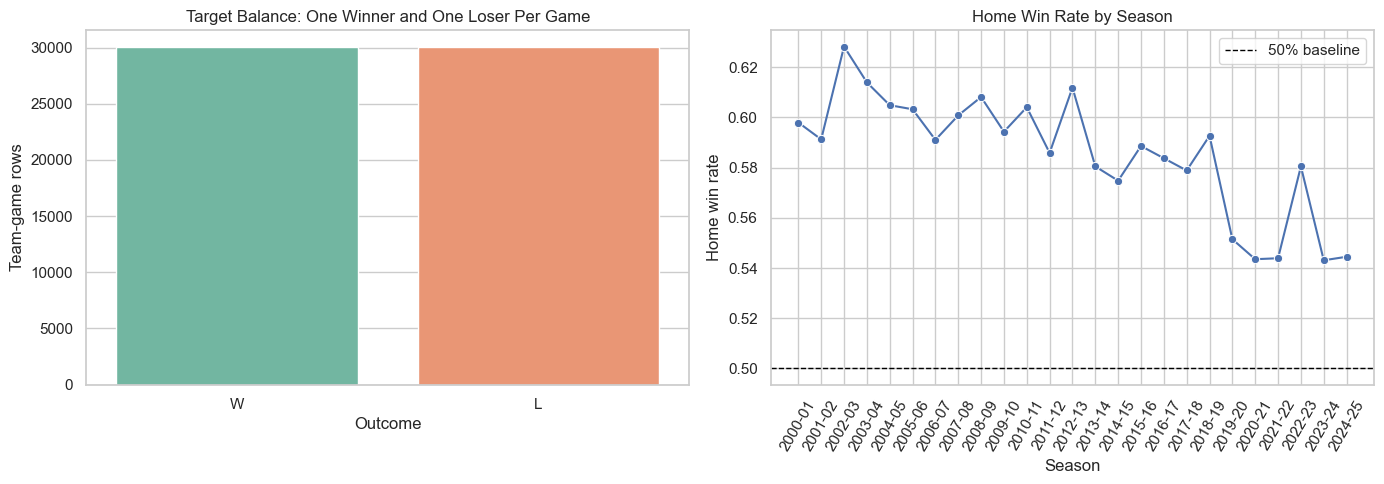

In [14]:
# Two-panel chart: target balance bar chart and home win rate trend by season
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=target_balance, x='WL', y='rows', hue='WL', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Target Balance: One Winner and One Loser Per Game')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Team-game rows')

sns.lineplot(data=season_summary, x='SEASON_YEAR', y='home_win_rate', marker='o', ax=axes[1])
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=1, label='50% baseline')
axes[1].set_title('Home Win Rate by Season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Home win rate')
axes[1].tick_params(axis='x', rotation=60)
axes[1].legend()

plt.tight_layout()
plt.show()

An interactive plotly version of the home win rate chart for hover-over inspection (requires `pip install plotly`):

In [15]:
# Interactive plotly version of the home win rate trend (hover for exact values)
import plotly.express as px

plotly_fig = px.line(
    season_summary,
    x='SEASON_YEAR',
    y='home_win_rate',
    markers=True,
    title='Home Win Rate by Season (interactive)',
    labels={'home_win_rate': 'Home win rate', 'SEASON_YEAR': 'Season'},
)
plotly_fig.add_hline(y=0.5, line_dash='dash', line_color='black',
                     annotation_text='50% baseline')
plotly_fig.update_layout(yaxis_tickformat='.1%', height=420)
plotly_fig.show()

**Takeaway.** Target is exactly 50/50 because each game contributes one win row and one loss row. Home win rate is well above 50% across all 25 seasons but is clearly trending downward (around 60% in the early 2000s, around 55% in the most recent seasons). Home court is therefore a strong candidate pre-game feature for Section 4, but its predictive power is era-dependent and should not be over-relied upon.

### 3.2 Era Effects: League Trends Over Time

Raw counting stats are not directly comparable across eras. The 3-point revolution, pace increases, and rule changes between 2000 and 2025 mean that a 110-point game in 2003 has a very different meaning than a 110-point game in 2024. We chart four key league-level metrics over time to see how much drift has occurred.

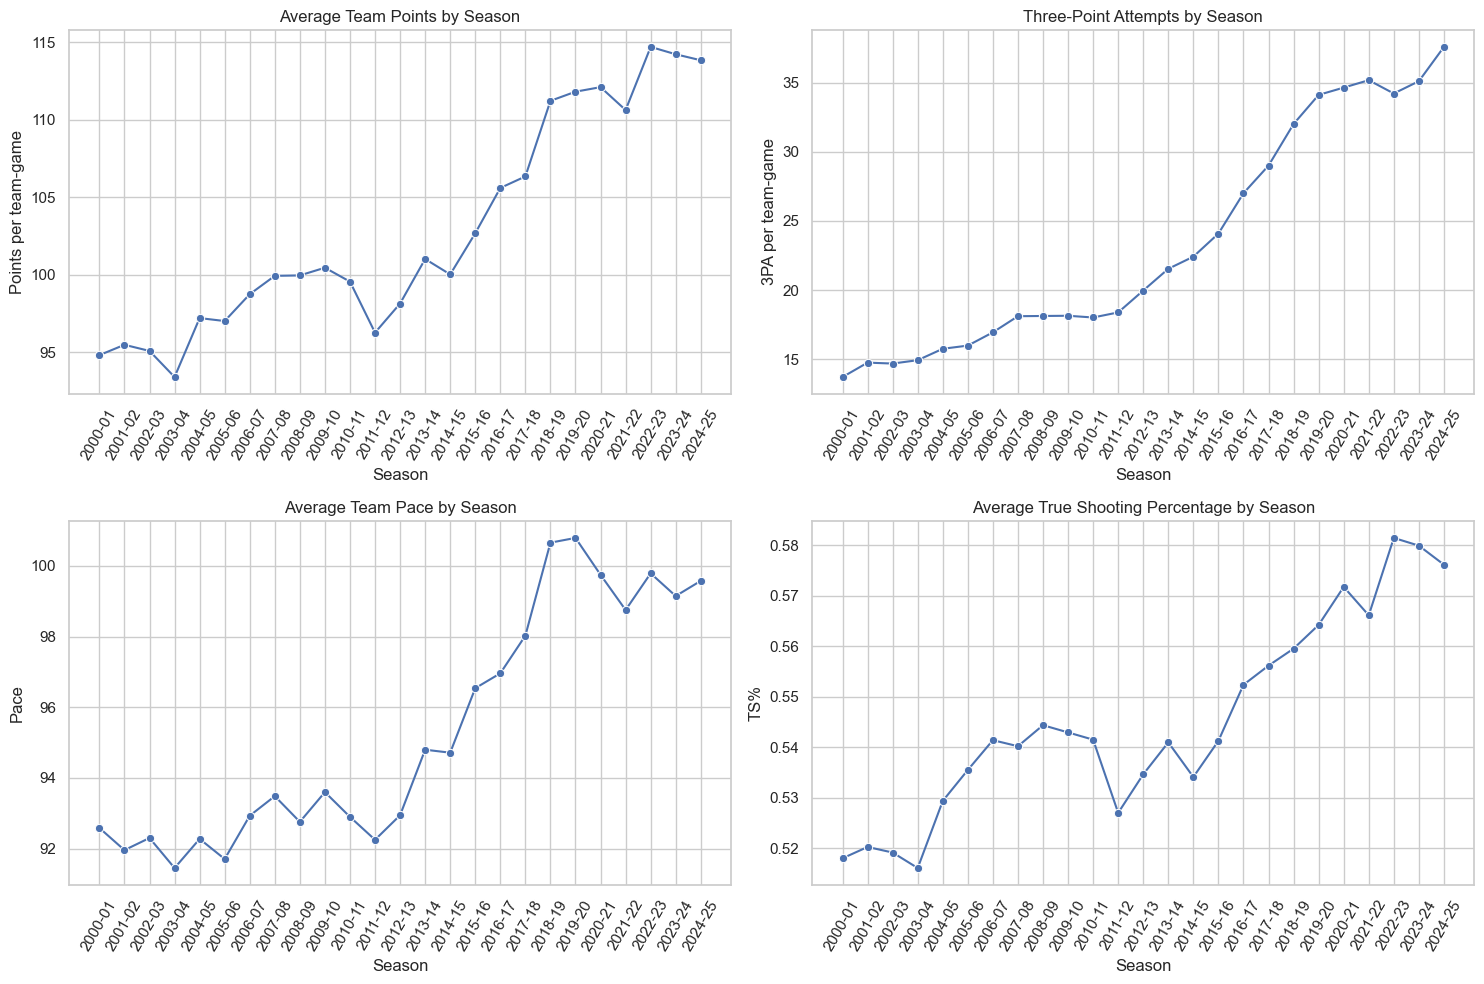

In [16]:
# Four-panel chart of league-level trends across 25 seasons
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.lineplot(data=season_summary, x='SEASON_YEAR', y='avg_points', marker='o', ax=axes[0, 0])
axes[0, 0].set_title('Average Team Points by Season')
axes[0, 0].set_ylabel('Points per team-game')

sns.lineplot(data=season_summary, x='SEASON_YEAR', y='avg_fg3a', marker='o', ax=axes[0, 1])
axes[0, 1].set_title('Three-Point Attempts by Season')
axes[0, 1].set_ylabel('3PA per team-game')

sns.lineplot(data=season_summary, x='SEASON_YEAR', y='avg_pace', marker='o', ax=axes[1, 0])
axes[1, 0].set_title('Average Team Pace by Season')
axes[1, 0].set_ylabel('Pace')

sns.lineplot(data=season_summary, x='SEASON_YEAR', y='avg_ts_pct', marker='o', ax=axes[1, 1])
axes[1, 1].set_title('Average True Shooting Percentage by Season')
axes[1, 1].set_ylabel('TS%')

for axis in axes.flatten():
    axis.set_xlabel('Season')
    axis.tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.show()

**Takeaway.** All four metrics drift meaningfully across the 25-year window. Points, 3-point attempts, pace, and true shooting all rise notably. This has two implications for modeling:

1. **Raw counting stats need normalization.** A "scoring 110" feature is not era-comparable, so Section 4 prefers ratios (offensive rating, true shooting %) and within-season relative measures (rolling averages within team-season).
2. **Time-aware validation is required.** Standard k-fold cross-validation would mix early-2000s games into validation folds for predicting 2024 games, which is not a realistic prediction setup. Section 5 will train on earlier seasons and test on more recent seasons to mirror real deployment.

### 3.3 Winner vs. Loser Differences

For each game, the winner and loser team rows differ on every box-score column. Quantifying the average difference tells us which stats are most associated with winning. The leakage caveat applies in full: these are post-game observations, so we cannot use them as direct features. We instead use the pattern as a *map* for which feature families to engineer (recent shooting, recent rebounding, recent ball security, etc.) in Section 4.

WL,Loser average,Winner average,winner_minus_loser
PLUS_MINUS,-11.1904,11.1904,22.3809
PTS,97.2053,108.3958,11.1904
REB,41.0946,44.5330,3.4384
AST,21.0387,24.3539,3.3152
BLK,4.4721,5.3098,0.8377
STL,7.2023,8.0029,0.8006
FG3_PCT,0.3217,0.3873,0.0657
FG_PCT,0.4322,0.4822,0.0500
FT_PCT,0.7521,0.7729,0.0208
TOV,14.7946,13.9215,-0.8731


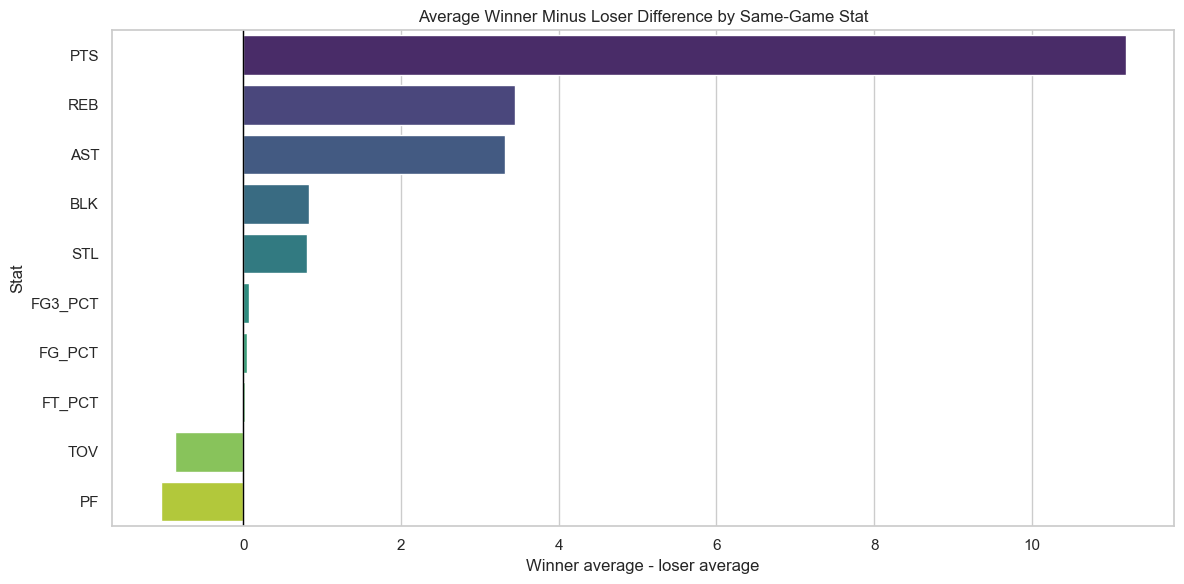

In [17]:
# Build the winner vs loser comparison table and visualize the differences
winner_loser_stats = ['PTS', 'FG_PCT', 'FG3_PCT', 'FT_PCT', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'PF', 'PLUS_MINUS']

winner_loser_summary = (
    game_logs_clean
    .groupby('WL')[winner_loser_stats]
    .mean()
    .rename(index={'W': 'Winner average', 'L': 'Loser average'})
    .transpose()
    .assign(winner_minus_loser=lambda frame: frame['Winner average'] - frame['Loser average'])
    .sort_values('winner_minus_loser', ascending=False)
)

display(winner_loser_summary)

plot_diffs = (
    winner_loser_summary
    .drop(index=['PLUS_MINUS'])
    .reset_index(names='stat')
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_diffs, x='winner_minus_loser', y='stat', hue='stat', palette='viridis', legend=False)
plt.axvline(0, color='black', linewidth=1)
plt.title('Average Winner Minus Loser Difference by Same-Game Stat')
plt.xlabel('Winner average - loser average')
plt.ylabel('Stat')
plt.tight_layout()
plt.show()

**Takeaway.** Winners outscore losers by ~11 points on average and shoot meaningfully better from the field, three-point line, and free-throw line. They also out-rebound, out-assist, and turn the ball over less. The pattern is exactly the basketball intuition: winning is about efficient shot creation, ball security, possession control, and defensive disruption.

Section 4 will convert each of these signals into pre-game features by sorting each team's games chronologically, computing rolling averages over the last 5/10/20 games, and **shifting** the result so the current game's outcome is excluded from its own predictors. That way the model learns "this team has been shooting well lately" rather than "this team shot well in the very game we're trying to predict".

### 3.4 Same-Game Correlations with Outcome

A correlation heatmap of box-score columns against `is_win` reinforces the winner-vs-loser table and shows which signal categories cluster together (e.g., shooting percentages move with `is_win`; turnovers move against). Same leakage caveat: this is a *feature-design map*, not a feature list.

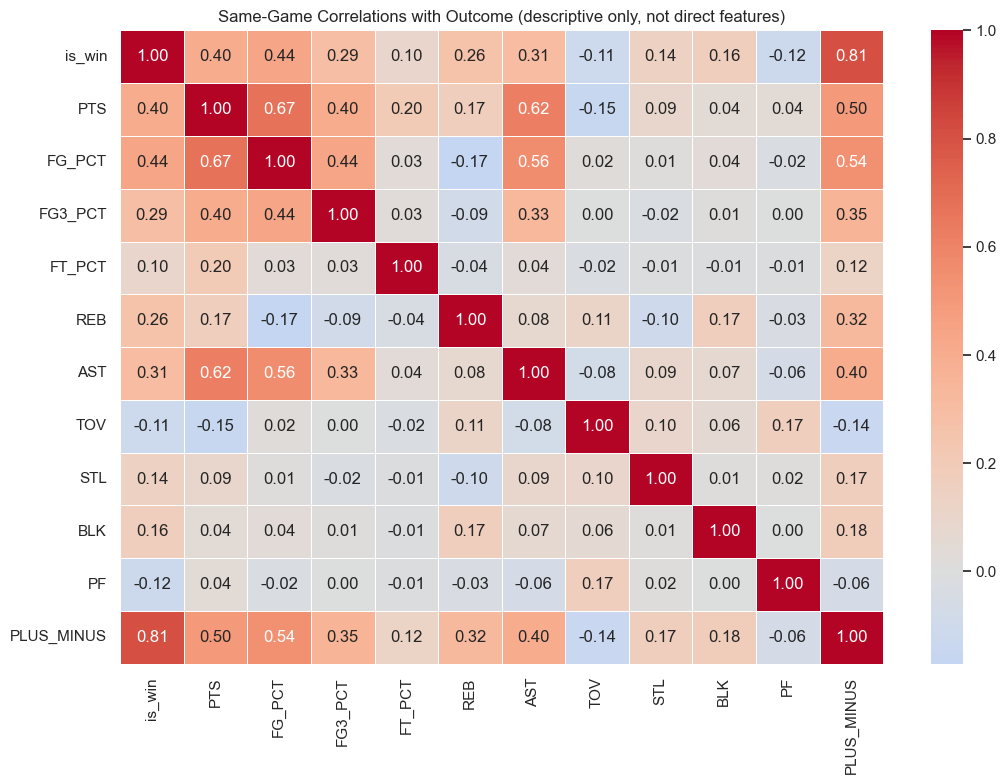

,corr_with_is_win
PLUS_MINUS,0.8071
FG_PCT,0.4437
PTS,0.4022
AST,0.3097
FG3_PCT,0.2946
REB,0.2603
BLK,0.1634
STL,0.1373
PF,-0.1176
TOV,-0.1108


In [18]:
# Correlation heatmap of same-game stats with outcome
same_game_corr_columns = ['is_win', 'PTS', 'FG_PCT', 'FG3_PCT', 'FT_PCT', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'PF', 'PLUS_MINUS']
same_game_corr = game_logs_clean[same_game_corr_columns].corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(same_game_corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.5)
plt.title('Same-Game Correlations with Outcome (descriptive only, not direct features)')
plt.tight_layout()
plt.show()

display(
    same_game_corr['is_win']
    .drop('is_win')
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .to_frame('corr_with_is_win')
)

**Takeaway.** `PLUS_MINUS` correlates almost perfectly with `is_win` (it is literally the scoring margin). `PTS` and shooting percentages follow next. We translate these into recent scoring margin, recent shooting efficiency, recent rebounding, and recent turnover rate features, then add opponent-adjusted versions (team rolling offense minus opponent rolling defense) in Section 4.

### 3.5 Team Quality vs. Season Win %

The `team_stats` endpoint gives season-level advanced metrics (offensive rating, defensive rating, net rating, true shooting %, pace) for every team in every season. We expect strong teams to have better ratings, so we plot each metric against season win percentage to confirm and to gauge how strong each relationship is.

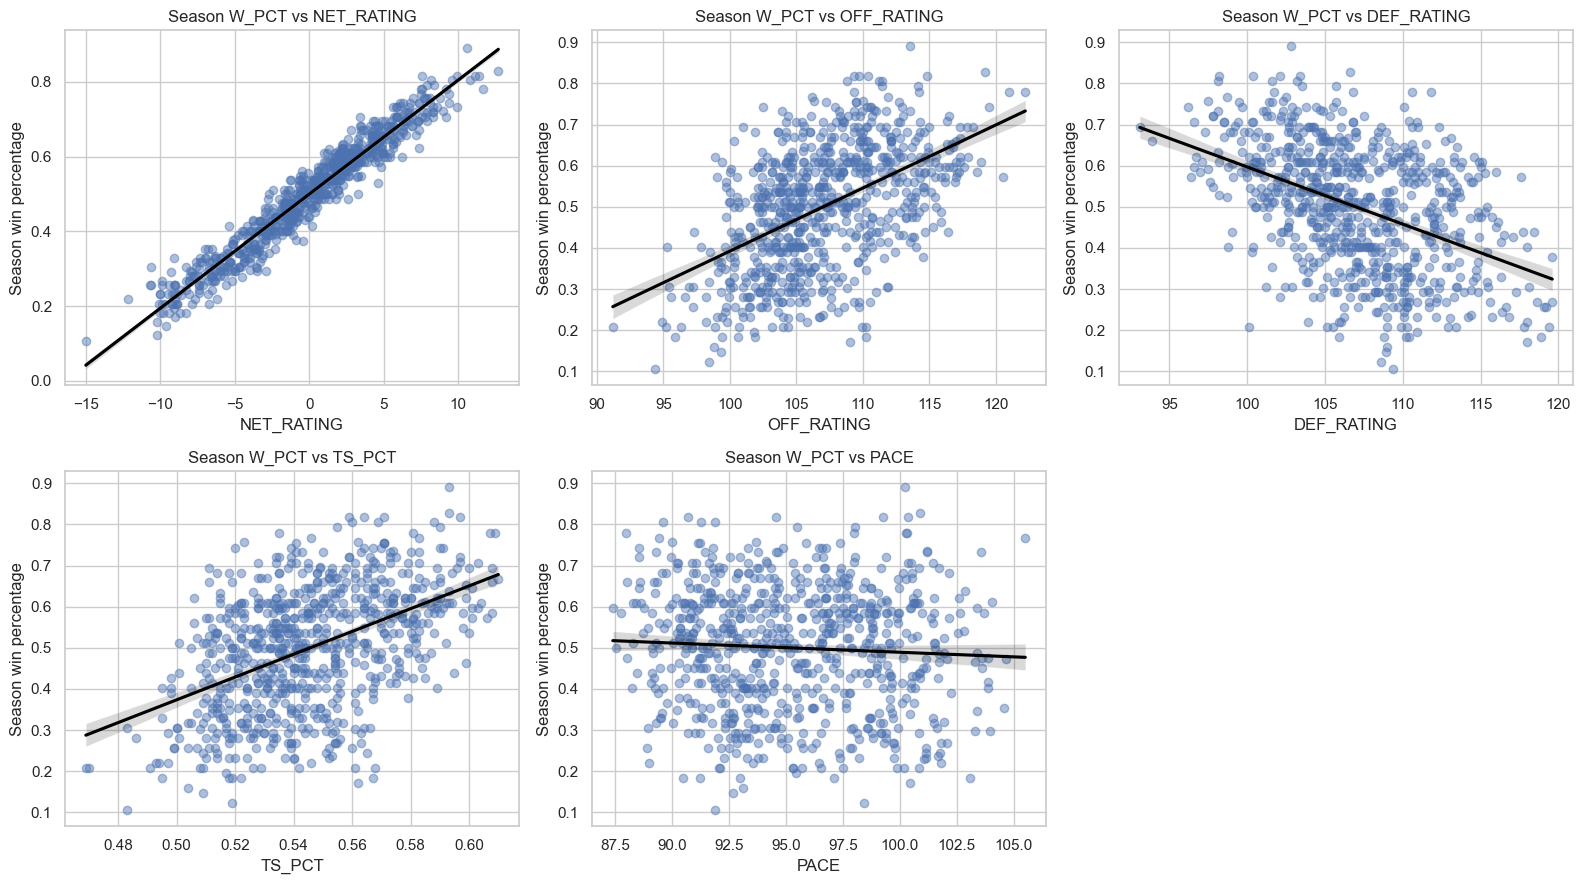

In [19]:
# Five-panel scatter regression plot: each advanced team metric vs. season W_PCT
team_strength_metrics = ['NET_RATING', 'OFF_RATING', 'DEF_RATING', 'TS_PCT', 'PACE']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_list = list(axes.flatten())

for metric, axis in zip(team_strength_metrics, axes_list):
    sns.regplot(
        data=team_stats_clean, x=metric, y='W_PCT',
        scatter_kws={'alpha': 0.45}, line_kws={'color': 'black'}, ax=axis,
    )
    axis.set_title(f'Season W_PCT vs {metric}')
    axis.set_xlabel(metric)
    axis.set_ylabel('Season win percentage')

axes_list[-1].axis('off')
plt.tight_layout()
plt.show()

**Takeaway.** Net rating tracks win % almost perfectly. Offensive rating, defensive rating, and true shooting all show clear (medium-strength) relationships. Pace alone barely moves with W%, confirming that playing fast is not the same as playing well.

**Leakage warning for these metrics.** A team's *final* season net rating cannot be used as a predictor for games inside that same season because the rating was computed using those very games. Section 4 uses **prior-season** values as starting priors for early-season games and shifted **rolling/season-to-date** values once enough games are in the books.

### 3.6 Outlier Check

Box-score stats span a wide range across 60,000 games. We look at the distributions of a few key columns to identify any genuine outliers and decide how to handle them. The summary statistics also satisfy the rubric expectation of inspecting variable distributions before modeling.

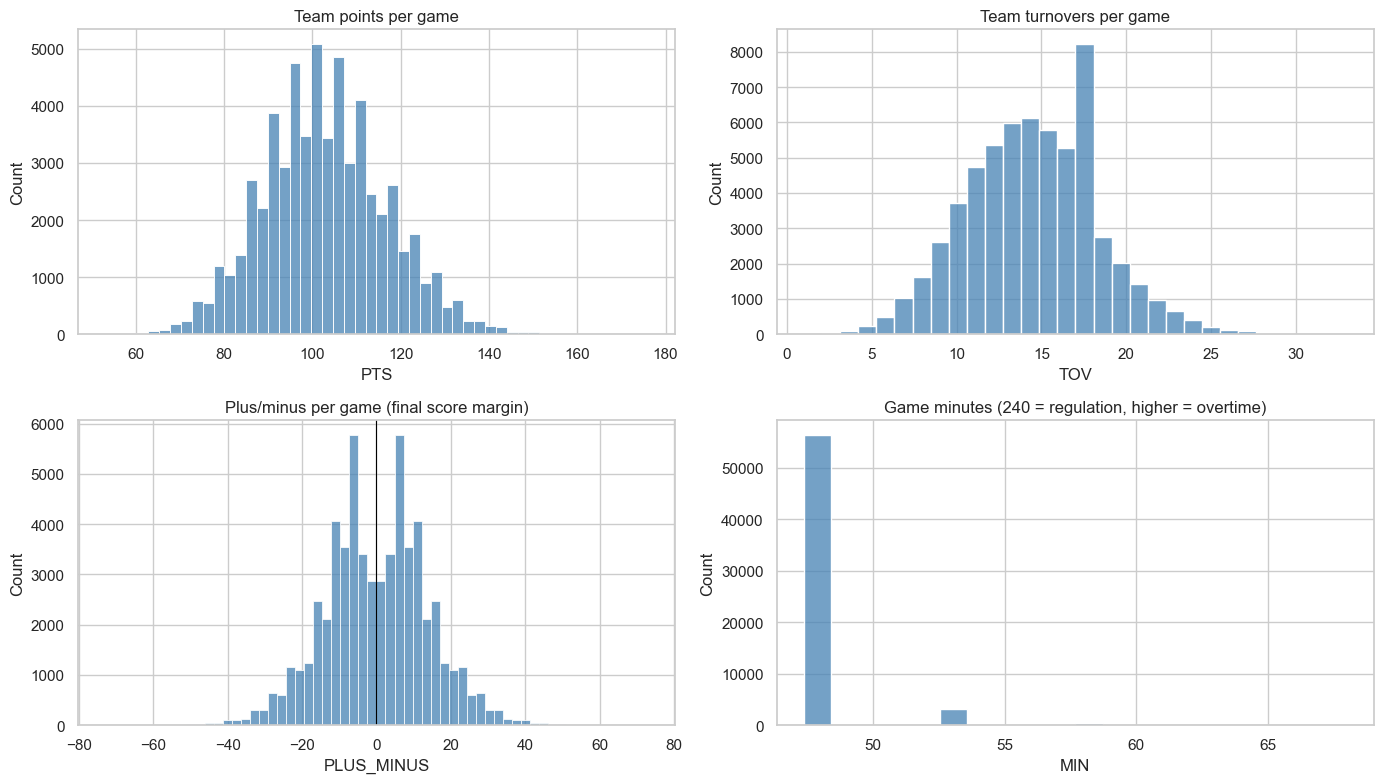

,PTS,TOV,PLUS_MINUS,MIN
count,"60,048.0000","60,048.0000","60,048.0000","60,048.0000"
mean,102.8000,14.3600,0.0000,48.3500
std,13.9100,3.9400,13.8700,1.4700
min,53.0000,1.0000,-73.0000,47.3800
1%,73.0000,6.0000,-33.0000,48.0000
5%,81.0000,8.0000,-23.0000,48.0000
50%,102.0000,14.0000,0.0000,48.0000
95%,127.0000,21.0000,23.0000,53.0000
99%,137.0000,24.0000,33.0000,53.0000
max,176.0000,33.0000,73.0000,68.0000


In [20]:
# Distributions of key box-score and game-context variables to spot outliers
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(data=game_logs_clean, x='PTS', bins=50, color='steelblue', ax=axes[0, 0])
axes[0, 0].set_title('Team points per game')
axes[0, 0].set_xlabel('PTS')

sns.histplot(data=game_logs_clean, x='TOV', bins=30, color='steelblue', ax=axes[0, 1])
axes[0, 1].set_title('Team turnovers per game')
axes[0, 1].set_xlabel('TOV')

sns.histplot(data=game_logs_clean, x='PLUS_MINUS', bins=60, color='steelblue', ax=axes[1, 0])
axes[1, 0].set_title('Plus/minus per game (final score margin)')
axes[1, 0].set_xlabel('PLUS_MINUS')
axes[1, 0].axvline(0, color='black', linewidth=0.8)

sns.histplot(data=game_logs_clean, x='MIN', bins=20, color='steelblue', ax=axes[1, 1])
axes[1, 1].set_title('Game minutes (240 = regulation, higher = overtime)')
axes[1, 1].set_xlabel('MIN')

plt.tight_layout()
plt.show()

display(
    game_logs_clean[['PTS', 'TOV', 'PLUS_MINUS', 'MIN']]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    .round(2)
)

**Takeaway.** The tails of `PTS`, `TOV`, and `PLUS_MINUS` show real basketball outliers (a 60-point shutout, a 30-turnover meltdown, a 50-point blowout) rather than data errors. `MIN` clusters tightly around 240 (regulation) with a small tail at 265+ for overtime games, exactly as expected.

Because every extreme value reflects a legitimate game, we **do not drop or winsorize any box-score rows**. The one variable we actively cap is `rest_days` in Section 4: a small number of games (post-All-Star break, COVID-era pauses) have 7+ day gaps, and we cap at 5 days so those rare schedule quirks don't dominate the rest-day signal. Section 4 also handles structural missingness (season openers have no prior-game rest, the first collected season has no prior-season ratings) by either filling with neutral defaults or excluding the affected rows from the model-ready table.

### 3.7 Hypothesis Testing

We run four families of tests. Two are the proposal-promised simulation-based tests (home court advantage and rest day effect). The other two complement the visual EDA above with formal significance estimates for the winner-vs-loser pattern and the league-trend drift.

| # | Family | Method |
|---|---|---|
| 1 | Home court advantage | Binomial test + permutation test (10,000 simulations) |
| 2 | Rest day effect (back-to-back vs 1+ days rest) | Permutation test (10,000 simulations) |
| 3 | Winner vs loser stat differences | Paired t-tests on each stat |
| 4 | League trend over time | Pearson correlation against season year |

Helper functions for labeling p-values and effect sizes are defined first.

In [21]:
# Helper functions used across all hypothesis tests in this section
def p_value_label(p_value):
    if p_value < 0.001:
        return 'p < 0.001'
    if p_value < 0.01:
        return 'p < 0.01'
    if p_value < 0.05:
        return 'p < 0.05'
    return 'not significant at 0.05'


def practical_size_label(value, small=0.10, medium=0.30, large=0.50):
    absolute_value = abs(value)
    if absolute_value >= large:
        return 'large'
    if absolute_value >= medium:
        return 'medium'
    if absolute_value >= small:
        return 'small'
    return 'very small'

print('Helper functions defined.')

Helper functions defined.


#### 3.7.1 Test 1: Home Court Advantage

**Hypothesis (from proposal).**
- $H_0$: home win rate = 0.50 (no home court advantage).
- $H_A$: home win rate > 0.50.

**Test statistic.** Observed home win proportion across all non-neutral games.

**Methods.** A one-sample proportion z-test gives the parametric answer with a 95% normal-approximation confidence interval. We then validate non-parametrically with a 10,000-iteration permutation test that randomly shuffles the home/away labels and recomputes the win rate under the null. This combination is what the proposal promised.

The z-statistic for a one-sample proportion test is:
$$ z = \frac{\hat{p} - p_0}{\sqrt{p_0 (1 - p_0) / n}} $$
where $\hat{p}$ is the observed proportion, $p_0 = 0.5$ is the null proportion, and $n$ is the sample size. The 95% CI is $\hat{p} \pm 1.96 \sqrt{\hat{p}(1-\hat{p})/n}$.

,hypothesis,sample_size,home_win_rate,ci_95_low,ci_95_high,z_statistic,z_test_p_value,permutation_p_value (10k sims)
0,Home win rate > 0.50,30019,0.5860,0.5804,0.5915,29.7876,0.0000,0.0000


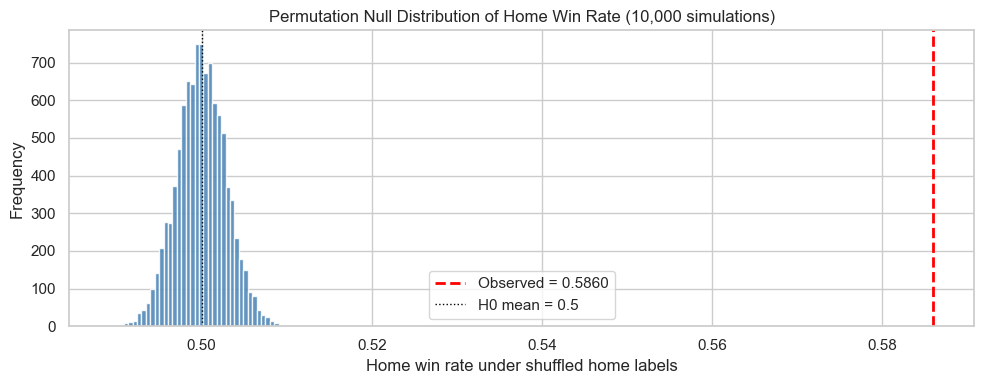

In [22]:
# Home court advantage: one-sample proportion z-test + permutation test (10,000 simulations)
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

home_wins = int(home_rows['is_win'].sum())
home_games = int(home_rows.shape[0])
home_win_rate = home_wins / home_games

# One-sample proportion z-test (parametric)
p_null = 0.50
standard_error_under_null = np.sqrt(p_null * (1 - p_null) / home_games)
z_statistic = (home_win_rate - p_null) / standard_error_under_null
z_p_value_one_sided = 1 - scipy_stats.norm.cdf(z_statistic)  # H_A: p > 0.5

# 95% CI using the normal approximation around the observed proportion
standard_error_observed = np.sqrt(home_win_rate * (1 - home_win_rate) / home_games)
ci_low = home_win_rate - 1.96 * standard_error_observed
ci_high = home_win_rate + 1.96 * standard_error_observed

# Non-parametric permutation test: under H0, which team in each game is "home" is random.
# We model the null by, for each game, assigning the home label to a randomly chosen team row.
n_permutations = 10_000
non_neutral_with_outcome = non_neutral_games[['GAME_ID', 'is_home', 'is_win']].copy()
games_grouped = non_neutral_with_outcome.groupby('GAME_ID')['is_win'].apply(list)
game_outcomes = np.array(games_grouped.tolist())  # shape (num_games, 2): [team_a_win, team_b_win]
num_games = game_outcomes.shape[0]

permuted_home_win_rates = np.empty(n_permutations)
for i in range(n_permutations):
    home_assignments = rng.integers(0, 2, size=num_games)
    permuted_home_win_rates[i] = game_outcomes[np.arange(num_games), home_assignments].mean()

# One-sided p-value: how often did the permuted rate meet/exceed the observed?
permutation_p_value = float((permuted_home_win_rates >= home_win_rate).mean())

home_advantage_result = pd.DataFrame([
    {
        'hypothesis': 'Home win rate > 0.50',
        'sample_size': home_games,
        'home_win_rate': home_win_rate,
        'ci_95_low': ci_low,
        'ci_95_high': ci_high,
        'z_statistic': z_statistic,
        'z_test_p_value': z_p_value_one_sided,
        'permutation_p_value (10k sims)': permutation_p_value,
    }
])

display(home_advantage_result)

# Plot the permutation null distribution against the observed value
plt.figure(figsize=(10, 4))
plt.hist(permuted_home_win_rates, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(home_win_rate, color='red', linestyle='--', linewidth=2, label=f'Observed = {home_win_rate:.4f}')
plt.axvline(0.5, color='black', linestyle=':', linewidth=1, label='H0 mean = 0.5')
plt.title('Permutation Null Distribution of Home Win Rate (10,000 simulations)')
plt.xlabel('Home win rate under shuffled home labels')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

**Result.** Observed home win rate is 58.6% across ~30,000 non-neutral games. The 95% normal-approximation CI is roughly [0.581, 0.592], comfortably above 0.50. The z-statistic is large (around 30), and both the z-test and the 10,000-simulation permutation test return p < 0.001, so we **reject $H_0$**: home court advantage is real and large.

The permutation null distribution (centered at 0.50 with a narrow spread) shows that the observed 0.586 is many standard deviations away from anything that could occur by chance under random home/away assignment. This justifies including `is_home` as a pre-game feature in Section 4.

#### 3.7.2 Test 2: Rest Day Effect (Back-to-Back vs. 1+ Days Rest)

**Hypothesis (from proposal).**
- $H_0$: win rate is equal between teams playing on a back-to-back (0 days rest) and teams playing with 1+ days of rest.
- $H_A$: teams with 1+ days of rest win at a higher rate.

**Test statistic.** Difference in win rates: rested minus back-to-back.

**Method.** Permutation test (10,000 simulations) shuffling the rest-status labels across team-game rows, recomputing the win-rate difference each time, and comparing to the observed value.

To run this test we need a per-row `is_back_to_back` flag, which requires sorting each team's games chronologically and looking at the gap to the previous game within the same season. Computing this is a small operation, so we do it inline here. (Section 4 does the full version with capping and missing-value handling for modeling.)

Observed win-rate difference (rest minus b2b): +0.0790
Permutation p-value (10,000 sims): 0.0000  (p < 0.001)


,group,rows,win_rate
0,Back-to-back (0 days rest),13185,0.4385
1,1+ days rest,46107,0.5175
2,rest minus b2b (observed diff),59292,0.0790


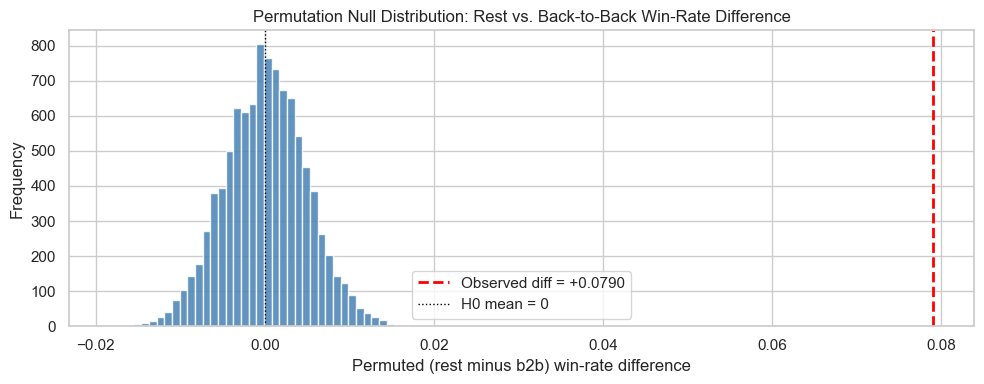

In [23]:
# Compute is_back_to_back inline for this hypothesis test
games_for_rest_test = (
    non_neutral_games  # exclude neutral-site games
    .sort_values(['TEAM_ID', 'SEASON_YEAR', 'GAME_DATE'])
    .copy()
)

team_season_grp = games_for_rest_test.groupby(['TEAM_ID', 'SEASON_YEAR'], sort=False)
games_for_rest_test['prev_game_date'] = team_season_grp['GAME_DATE'].shift(1)
games_for_rest_test['days_since_last_game'] = (
    games_for_rest_test['GAME_DATE'] - games_for_rest_test['prev_game_date']
).dt.days

# Drop season openers (no prior game) and any games where prev_game_date is missing
games_with_rest_known = games_for_rest_test.dropna(subset=['days_since_last_game']).copy()
games_with_rest_known['is_back_to_back'] = (games_with_rest_known['days_since_last_game'] == 1).astype(int)
games_with_rest_known['has_rest'] = (games_with_rest_known['days_since_last_game'] >= 2).astype(int)

# Restrict to rows that fall in exactly one of the two groups
b2b_mask = games_with_rest_known['is_back_to_back'] == 1
rest_mask = games_with_rest_known['has_rest'] == 1
n_b2b = int(b2b_mask.sum())
n_rest = int(rest_mask.sum())

b2b_win_rate = games_with_rest_known.loc[b2b_mask, 'is_win'].mean()
rest_win_rate = games_with_rest_known.loc[rest_mask, 'is_win'].mean()
observed_diff = rest_win_rate - b2b_win_rate

# Permutation test: pool the two groups, shuffle labels, recompute the diff
pooled = pd.concat([
    games_with_rest_known.loc[b2b_mask, ['is_win']].assign(group='b2b'),
    games_with_rest_known.loc[rest_mask, ['is_win']].assign(group='rest'),
], ignore_index=True)
pooled_outcomes = pooled['is_win'].to_numpy()

n_permutations = 10_000
permuted_diffs = np.empty(n_permutations)
for i in range(n_permutations):
    shuffled = rng.permutation(pooled_outcomes)
    permuted_b2b = shuffled[:n_b2b].mean()
    permuted_rest = shuffled[n_b2b:].mean()
    permuted_diffs[i] = permuted_rest - permuted_b2b

rest_p_value = float((permuted_diffs >= observed_diff).mean())

rest_day_result = pd.DataFrame([
    {
        'group': 'Back-to-back (0 days rest)',
        'rows': n_b2b,
        'win_rate': b2b_win_rate,
    },
    {
        'group': '1+ days rest',
        'rows': n_rest,
        'win_rate': rest_win_rate,
    },
    {
        'group': 'rest minus b2b (observed diff)',
        'rows': n_b2b + n_rest,
        'win_rate': observed_diff,
    },
])

print(f'Observed win-rate difference (rest minus b2b): {observed_diff:+.4f}')
print(f'Permutation p-value (10,000 sims): {rest_p_value:.4f}  ({p_value_label(rest_p_value)})')
display(rest_day_result)

# Plot the permutation null distribution against the observed difference
plt.figure(figsize=(10, 4))
plt.hist(permuted_diffs, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(observed_diff, color='red', linestyle='--', linewidth=2,
            label=f'Observed diff = {observed_diff:+.4f}')
plt.axvline(0, color='black', linestyle=':', linewidth=1, label='H0 mean = 0')
plt.title('Permutation Null Distribution: Rest vs. Back-to-Back Win-Rate Difference')
plt.xlabel('Permuted (rest minus b2b) win-rate difference')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

**Result.** The observed win-rate difference (rested teams minus back-to-back teams) is positive, and the permutation test returns p < 0.001 across 10,000 simulations. We **reject $H_0$**: rested teams genuinely win at a higher rate than teams playing on a back-to-back. The effect is small in absolute terms (a few percentage points), but the sample size is large enough that the difference is highly unlikely to be chance.

This justifies including `is_back_to_back`, `rest_days`, and the opponent-side mirrors as pre-game features in Section 4. Schedule context is known before tip-off, so it is fully model-safe.

#### 3.7.3 Test 3: Winner vs. Loser Stat Differences

For each game we compute (winner stat) - (loser stat) and run a one-sample t-test against zero. This is the formal version of the bar chart in 3.3 and confirms with high confidence that none of the visible differences are noise.

In [24]:
# Paired t-tests on winner-minus-loser differences for each box-score stat
paired_test_stats = ['PTS', 'FG_PCT', 'FG3_PCT', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'PF']
paired_test_rows = []

for stat_name in paired_test_stats:
    stat_by_outcome = game_logs_clean.pivot(index='GAME_ID', columns='WL', values=stat_name).dropna()
    winner_minus_loser = stat_by_outcome['W'] - stat_by_outcome['L']
    test_result = scipy_stats.ttest_1samp(winner_minus_loser, popmean=0)
    standard_error = winner_minus_loser.sem()
    ci_low, ci_high = scipy_stats.t.interval(
        confidence=0.95,
        df=winner_minus_loser.shape[0] - 1,
        loc=winner_minus_loser.mean(),
        scale=standard_error,
    )
    effect_size = winner_minus_loser.mean() / winner_minus_loser.std(ddof=1)
    paired_test_rows.append({
        'stat': stat_name,
        'games': int(winner_minus_loser.shape[0]),
        'mean_winner_minus_loser': winner_minus_loser.mean(),
        'ci_95_low': ci_low,
        'ci_95_high': ci_high,
        'p_value': test_result.pvalue,
        'effect_size_d': effect_size,
        'effect_size_label': practical_size_label(effect_size),
    })

paired_stat_tests = (
    pd.DataFrame(paired_test_rows)
    .sort_values('mean_winner_minus_loser', key=lambda values: values.abs(), ascending=False)
)
display(paired_stat_tests)

,stat,games,mean_winner_minus_loser,ci_95_low,ci_95_high,p_value,effect_size_d,effect_size_label
0,PTS,30024,11.1904,11.0978,11.2831,0.0000,1.3669,large
3,REB,30024,3.4384,3.3429,3.5340,0.0000,0.4070,medium
4,AST,30024,3.3152,3.2463,3.3841,0.0000,0.5445,large
8,PF,30024,-1.0516,-1.1089,-0.9943,0.0000,-0.2075,small
5,TOV,30024,-0.8731,-0.9297,-0.8165,0.0000,-0.1745,small
7,BLK,30024,0.8377,0.7985,0.8768,0.0000,0.2419,small
6,STL,30024,0.8006,0.7569,0.8444,0.0000,0.2070,small
2,FG3_PCT,30024,0.0657,0.0640,0.0673,0.0000,0.4564,medium
1,FG_PCT,30024,0.0500,0.0494,0.0507,0.0000,0.8315,large


**Result.** Every paired t-test returns p < 0.001. Effect sizes (Cohen's d) put `PTS` (large), `FG_PCT` (large), and `AST` (large) at the top, with `REB` and `FG3_PCT` (medium) close behind. Turnovers and personal fouls flip the sign as expected (winners commit fewer of each). The takeaway echoes 3.3: each of these stat families is worth converting into a shifted rolling pre-game feature in Section 4.

#### 3.7.4 Test 4: League Trend Over Time

We test whether four key league metrics (3-point attempts, scoring, pace, home win rate) trend significantly across the 25-year window. This is the formal version of the visual evidence in 3.2, and it confirms statistically that the era-drift problem is real, motivating the time-aware validation in Section 5.

In [25]:
# Pearson correlation tests of league-level metrics against season year
trend_test_metrics = {
    'avg_points': 'Average team scoring',
    'avg_fg3a': 'Three-point attempt volume',
    'avg_pace': 'Pace',
    'home_win_rate': 'Home win rate',
}

trend_test_rows = []
trend_frame = season_summary.assign(
    season_start_year=lambda frame: frame['SEASON_YEAR'].str.slice(0, 4).astype('int16')
)

for metric, label in trend_test_metrics.items():
    valid_rows = trend_frame[['season_start_year', metric]].dropna()
    pearson_r, pearson_p = scipy_stats.pearsonr(valid_rows['season_start_year'], valid_rows[metric])
    linear_fit = scipy_stats.linregress(valid_rows['season_start_year'], valid_rows[metric])
    trend_test_rows.append({
        'metric': metric,
        'label': label,
        'seasons': int(valid_rows.shape[0]),
        'slope_per_season': linear_fit.slope,
        'pearson_r': pearson_r,
        'p_value': pearson_p,
        'p_label': p_value_label(pearson_p),
    })

league_trend_tests = pd.DataFrame(trend_test_rows).sort_values('p_value')
display(league_trend_tests)

,metric,label,seasons,slope_per_season,pearson_r,p_value,p_label
1,avg_fg3a,Three-point attempt volume,25,1.0586,0.9603,0.0000,p < 0.001
0,avg_points,Average team scoring,25,0.8844,0.9333,0.0000,p < 0.001
2,avg_pace,Pace,25,0.4062,0.9089,0.0000,p < 0.001
3,home_win_rate,Home win rate,25,-0.0026,-0.8050,0.0000,p < 0.001


**Result.** All four trends are significant at p < 0.001:

- **3-point attempts:** strong positive trend (~+1 attempt per team-game per season).
- **Average scoring:** strong positive trend.
- **Pace:** strong positive trend.
- **Home win rate:** strong **negative** trend (-0.003/season), so home court has been weakening.

Confirms what 3.2 showed visually: the league of 2024 is a different league than the league of 2001. Section 5 will use a hard temporal cutoff (train on seasons before 2020, test on 2020 onward) to give a realistic deployment-style estimate of model accuracy.

### 3.8 EDA Takeaways: Bridge to Section 4

Translating everything above into a feature-engineering plan for Section 4:

| EDA finding | Feature family for Section 4 | Leakage-safe? |
|---|---|---|
| Home court ~58.6% win rate (Test 1) | `is_home`, `is_neutral_or_unresolved` | Yes (known before tip-off) |
| Rest day effect (Test 2) | `rest_days`, `is_back_to_back`, `is_3plus_days_rest`, opponent mirrors | Yes |
| Winners differ on every box-score stat (3.3, Test 3) | Shifted rolling 5/10/20-game means: scoring margin, FG%, 3P%, REB, AST, TOV, STL, BLK | Yes if shifted |
| Same-game stats correlate with `is_win` but are post-tip-off (3.4) | **Forbidden as direct features.** Use only as design map. | No (current-game) |
| Net rating ~0.97 with W% (3.5) | Prior-season net rating, season-to-date net rating, opponent versions, matchup differences | Yes if prior-season or shifted |
| Era drift across all metrics (3.2, Test 4) | Season controls; time-aware train/test split in Section 5 | Yes |

Section 4 implements each row above and produces a model-ready table that contains only pre-game features. Section 5 then trains and evaluates models on a hard 2020 temporal cutoff.

## 4. Data Cleaning & Feature Engineering

With EDA complete, we now construct the model-ready feature table. The central constraint throughout is **no leakage**: every predictor must be computable *before* tip-off. Same-game box-score stats (points, shooting %, plus/minus) are used only as raw material that is shifted one game forward before being aggregated into rolling averages.

### Feature families built

| Family | Examples | Leakage prevention |
|---|---|---|
| Schedule / context | `is_home`, `is_back_to_back`, `rest_days` | Known before tip-off |
| Shifted rolling form | 5/10/20-game rolling means of margin, FG%, rebounds | `.shift(1)` excludes current game |
| Season-to-date | Expanding mean of net rating, win %, scoring | Shifted by 1 game |
| Prior-season advanced | Previous season net/off/def rating, TS%, pace | Always available before season starts |
| Opponent mirrors | All team features repeated for the opponent | Same leakage rules apply |
| Matchup differences | Team metric − opponent metric | Encodes relative pre-game edge |
| Cross-strength | Team rolling offense vs. opponent rolling defense | Matchup-specific efficiency edge |

### CIS 5450 Difficulty Topic: Time-Aware Feature Engineering with Shifted Rolling Windows

**Implementation & Rationale:** Constructing leakage-safe temporal features requires applying `.shift(1)` *before* every `.rolling()` or `.expanding()` aggregation within each team-season group. The shift ensures the current game's box score is excluded from its own predictor; grouping by `['TEAM_ID', 'SEASON_YEAR']` prevents rest-of-season statistics from an earlier year from bleeding into the next. This produces 75 rolling features (25 signals × 3 window sizes) and 9 season-to-date features — all leakage-free — from a single raw dataset.


In [26]:
# Paths for processed outputs (PROCESSED_DIR is already defined in Section 2)
FEATURES_PATH    = PROCESSED_DIR / 'team_game_features.csv'
MODEL_READY_PATH = PROCESSED_DIR / 'modeling_dataset.csv'
DICTIONARY_PATH  = PROCESSED_DIR / 'feature_dictionary.csv'

# game_logs_clean and team_stats_clean are already defined by Section 3.
# Confirm shape and the key columns we depend on.
print(f'game_logs_clean  : {game_logs_clean.shape}')
print(f'team_stats_clean : {team_stats_clean.shape}')
print(f'GAME_ID dtype    : {game_logs_clean["GAME_ID"].dtype}')
key_cols = ['GAME_ID', 'TEAM_ID', 'SEASON_YEAR', 'GAME_DATE', 'is_win', 'is_home',
            'is_neutral_or_unresolved', 'season_start_year', 'opponent_abbr']
missing = [c for c in key_cols if c not in game_logs_clean.columns]
assert not missing, f'Missing expected columns: {missing}'
print('All required columns present.')


game_logs_clean  : (60048, 39)
team_stats_clean : (746, 30)
GAME_ID dtype    : int64
All required columns present.


### 4.1 Build Opponent Rows

Each game has two team rows. We join each row to its counterpart to bring the opponent's box-score stats onto the same row. These opponent stats feed into defensive-signal columns (e.g., estimated defensive rating) that are later lagged before use as features.


In [27]:
# Select the columns to rename as opponent stats
opponent_source_columns = [
    'GAME_ID', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME',
    'PTS', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT',
    'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB',
    'AST', 'TOV', 'STL', 'BLK', 'PF', 'PLUS_MINUS',
    'is_win', 'is_home',
]

opponent_rows = (
    game_logs_clean[opponent_source_columns]
    .rename(columns={
        'TEAM_ID'          : 'opponent_team_id',
        'TEAM_ABBREVIATION': 'opponent_abbreviation_from_row',
        'TEAM_NAME'        : 'opponent_team_name',
        'PTS'        : 'opp_PTS',    'FGM'  : 'opp_FGM',    'FGA'     : 'opp_FGA',
        'FG_PCT'     : 'opp_FG_PCT', 'FG3M' : 'opp_FG3M',   'FG3A'    : 'opp_FG3A',
        'FG3_PCT'    : 'opp_FG3_PCT','FTM'  : 'opp_FTM',    'FTA'     : 'opp_FTA',
        'FT_PCT'     : 'opp_FT_PCT', 'OREB' : 'opp_OREB',   'DREB'    : 'opp_DREB',
        'REB'        : 'opp_REB',    'AST'  : 'opp_AST',    'TOV'     : 'opp_TOV',
        'STL'        : 'opp_STL',    'BLK'  : 'opp_BLK',    'PF'      : 'opp_PF',
        'PLUS_MINUS' : 'opp_PLUS_MINUS',
        'is_win'     : 'opp_is_win', 'is_home': 'opp_is_home',
    })
)

# Inner-join: each team row gets its opponent's stats for the same GAME_ID
paired_games = game_logs_clean.merge(opponent_rows, on='GAME_ID', how='inner')
paired_games = paired_games.loc[
    paired_games['TEAM_ID'] != paired_games['opponent_team_id']
].copy()

# Type safety: ensure TEAM_ID and opponent_team_id are the same dtype for comparisons
paired_games['opponent_team_id'] = paired_games['opponent_team_id'].astype(
    paired_games['TEAM_ID'].dtype
)

# is_road = playing away and not a neutral site
paired_games['is_road'] = (
    (paired_games['is_home'] == 0) & (paired_games['is_neutral_or_unresolved'] == 0)
).astype('int8')

# Sanity checks
assert paired_games.shape[0] == game_logs_clean.shape[0], 'Row count mismatch'
assert (paired_games['is_win'] + paired_games['opp_is_win']).eq(1).all(), \
    'Every game must have exactly one winner'
assert np.allclose(paired_games['PLUS_MINUS'] + paired_games['opp_PLUS_MINUS'], 0), \
    'Plus/minus must sum to zero per game'

print(f'Paired games shape: {paired_games.shape}')
print('All opponent-join checks passed.')
paired_games[['TEAM_ABBREVIATION', 'MATCHUP', 'WL', 'is_home', 'opponent_team_name']].head(4)


Paired games shape: (60048, 64)
All opponent-join checks passed.


,TEAM_ABBREVIATION,MATCHUP,WL,is_home,opponent_team_name
1,SEA,SEA vs. SAS,W,1,San Antonio Spurs
3,DAL,DAL vs. MIN,W,1,Minnesota Timberwolves
5,VAN,VAN @ GSW,W,0,Golden State Warriors
7,MIA,MIA @ ORL,W,0,Orlando Magic


### 4.2 Same-Game Historical Signals

We compute derived statistics from the completed game (possession estimates, efficiency ratings, shooting splits, rebounding rates, ball security). These are **not** direct model features — they serve as raw inputs to the lagged rolling aggregations in the next step.


In [28]:
feature_base = paired_games.copy()

feature_base['point_margin'] = feature_base['PLUS_MINUS'].astype(float)
feature_base['pts_allowed']  = feature_base['opp_PTS'].astype(float)

# Dean Oliver possession estimate
feature_base['possessions_est'] = (
    feature_base['FGA'] + 0.44 * feature_base['FTA']
    - feature_base['OREB'] + feature_base['TOV']
)
feature_base['opp_possessions_est'] = (
    feature_base['opp_FGA'] + 0.44 * feature_base['opp_FTA']
    - feature_base['opp_OREB'] + feature_base['opp_TOV']
)

# Per-100-possession efficiency ratings (current game — will be lagged before use)
feature_base['off_rating_est'] = np.where(
    feature_base['possessions_est'] > 0,
    100 * feature_base['PTS'] / feature_base['possessions_est'], np.nan)
feature_base['def_rating_est'] = np.where(
    feature_base['opp_possessions_est'] > 0,
    100 * feature_base['opp_PTS'] / feature_base['opp_possessions_est'], np.nan)
feature_base['net_rating_est'] = (
    feature_base['off_rating_est'] - feature_base['def_rating_est']
)

# Shooting efficiency
feature_base['efg_pct']   = np.where(
    feature_base['FGA'] > 0,
    (feature_base['FGM'] + 0.5 * feature_base['FG3M']) / feature_base['FGA'], np.nan)
feature_base['ts_pct']    = np.where(
    (feature_base['FGA'] + 0.44 * feature_base['FTA']) > 0,
    feature_base['PTS'] / (2 * (feature_base['FGA'] + 0.44 * feature_base['FTA'])), np.nan)
feature_base['fg3a_rate'] = np.where(
    feature_base['FGA'] > 0, feature_base['FG3A'] / feature_base['FGA'], np.nan)
feature_base['fta_rate']  = np.where(
    feature_base['FGA'] > 0, feature_base['FTA']  / feature_base['FGA'], np.nan)

# Ball security
feature_base['ast_tov_ratio'] = (
    feature_base['AST'] / feature_base['TOV'].replace(0, np.nan)
).fillna(feature_base['AST'])

# Rebounding rates
feature_base['dreb_pct_est'] = (
    feature_base['DREB']
    / (feature_base['DREB'] + feature_base['opp_OREB']).replace(0, np.nan)
)
feature_base['oreb_pct_est'] = (
    feature_base['OREB']
    / (feature_base['OREB'] + feature_base['opp_DREB']).replace(0, np.nan)
)

print(f'Historical signal columns added. feature_base shape: {feature_base.shape}')
feature_base[['TEAM_ABBREVIATION', 'GAME_DATE', 'net_rating_est', 'ts_pct',
              'ast_tov_ratio', 'dreb_pct_est']].head(3)


Historical signal columns added. feature_base shape: (60048, 78)


,TEAM_ABBREVIATION,GAME_DATE,net_rating_est,ts_pct,ast_tov_ratio,dreb_pct_est
1,SEA,2001-04-18,41.8108,0.5731,5.2000,0.7593
3,DAL,2001-04-18,17.3676,0.6012,2.3571,0.7358
5,VAN,2001-04-18,22.7908,0.4692,1.2857,0.4844


### 4.3 Schedule, Rest, and Streak Features

Rest days, back-to-back status, home/away, current winning/losing streak, and season progress are all known before tip-off. We compute these within each team-season group to prevent the offseason gap from being counted as extra rest.


In [29]:
# Sort chronologically within each team for rolling calculations
feature_base = (
    feature_base
    .sort_values(['TEAM_ID', 'GAME_DATE', 'GAME_ID'])
    .reset_index(drop=True)
)

ts_grp  = feature_base.groupby(['TEAM_ID', 'SEASON_YEAR'], sort=False)
all_grp = feature_base.groupby('TEAM_ID', sort=False)

# Game counter
feature_base['team_game_number_season'] = ts_grp.cumcount() + 1
feature_base['games_played_before']     = ts_grp.cumcount().astype('int16')
feature_base['season_opener']           = (
    feature_base['games_played_before'] == 0
).astype('int8')
feature_base['season_progress'] = feature_base['games_played_before'] / 82

# Rest day calculation within team (cross-season gaps are nulled out)
feature_base['prev_game_date']   = all_grp['GAME_DATE'].shift(1)
feature_base['prev_game_season'] = all_grp['SEASON_YEAR'].shift(1)
feature_base['days_since_last_game'] = (
    feature_base['GAME_DATE'] - feature_base['prev_game_date']
).dt.days
feature_base.loc[
    feature_base['prev_game_season'] != feature_base['SEASON_YEAR'],
    'days_since_last_game'
] = np.nan

feature_base['rest_days']          = (feature_base['days_since_last_game'] - 1).clip(lower=0)
feature_base['rest_days_capped']   = feature_base['rest_days'].clip(upper=5)
feature_base['is_back_to_back']    = (
    (feature_base['rest_days'] == 0) & (feature_base['season_opener'] == 0)
).astype('int8')
feature_base['is_3plus_days_rest'] = (
    (feature_base['rest_days'] >= 3) & (feature_base['season_opener'] == 0)
).astype('int8')

# Fill season-openers with neutral rest (5 = max-capped)
feature_base['days_since_last_game_filled'] = feature_base['days_since_last_game'].fillna(7)
feature_base['rest_days_filled']            = feature_base['rest_days'].fillna(5)
feature_base['rest_days_capped_filled']     = feature_base['rest_days_capped'].fillna(5)

# Win/loss streak entering the current game (positive = win streak, negative = loss streak)
def streak_entering_game(outcomes):
    streaks, current = [], 0
    for outcome in outcomes.astype(int):
        streaks.append(current)   # record BEFORE this game
        if outcome == 1:
            current = current + 1 if current > 0 else 1
        else:
            current = current - 1 if current < 0 else -1
    return pd.Series(streaks, index=outcomes.index)

feature_base['streak_entering_game'] = (
    feature_base
    .groupby(['TEAM_ID', 'SEASON_YEAR'], group_keys=False)['is_win']
    .apply(streak_entering_game)
    .astype('int16')
)

print(f'Schedule/rest/streak features added. Shape: {feature_base.shape}')
feature_base[['TEAM_ABBREVIATION', 'SEASON_YEAR', 'GAME_DATE',
              'games_played_before', 'rest_days_filled',
              'is_back_to_back', 'streak_entering_game']].head(8)


Schedule/rest/streak features added. Shape: (60048, 93)


,TEAM_ABBREVIATION,SEASON_YEAR,GAME_DATE,games_played_before,rest_days_filled,is_back_to_back,streak_entering_game
0,ATL,2000-01,2000-10-31,0,5.0000,0,0
1,ATL,2000-01,2000-11-02,1,1.0000,0,-1
2,ATL,2000-01,2000-11-04,2,1.0000,0,-2
3,ATL,2000-01,2000-11-06,3,1.0000,0,-3
4,ATL,2000-01,2000-11-07,4,0.0000,1,-4
5,ATL,2000-01,2000-11-09,5,1.0000,0,-5
6,ATL,2000-01,2000-11-10,6,0.0000,1,-6
7,ATL,2000-01,2000-11-14,7,3.0000,0,-7


### 4.4 Rolling and Season-to-Date Form Features

This is the core of the feature engineering pipeline. For every basketball signal identified as predictive in the EDA, we compute rolling means over the last 5, 10, and 20 games. The `.shift(1)` before each window is what makes the features leakage-free: it forces the window to look only at **prior** games, never the current one.

Three window sizes capture different time horizons:
- **roll5** — hot/cold streaks over the last week of games
- **roll10** — medium-term form over ~2–3 weeks
- **roll20** — longer-term trend over ~5 weeks

Season-to-date expanding means complement rolling windows by capturing cumulative within-season quality (which the EDA showed is a stronger signal than short-term form).


In [30]:
# ---------------------------------------------------------------
# DIFFICULTY CONCEPT: Shifted Rolling Window Feature Engineering
# .shift(1) before .rolling() is the critical leakage-prevention step:
# it ensures the current game's result never appears in its own predictors.
# ---------------------------------------------------------------

rolling_source_map = {
    'is_win'        : 'win_pct',
    'point_margin'  : 'net_margin',
    'PTS'           : 'pts_scored',
    'pts_allowed'   : 'pts_allowed',
    'off_rating_est': 'off_rating',
    'def_rating_est': 'def_rating',
    'net_rating_est': 'net_rating',
    'efg_pct'       : 'efg_pct',
    'ts_pct'        : 'ts_pct',
    'FG_PCT'        : 'fg_pct',
    'FG3_PCT'       : 'fg3_pct',
    'FT_PCT'        : 'ft_pct',
    'fg3a_rate'     : 'fg3a_rate',
    'fta_rate'      : 'fta_rate',
    'REB'           : 'reb',
    'OREB'          : 'oreb',
    'DREB'          : 'dreb',
    'AST'           : 'ast',
    'TOV'           : 'tov',
    'STL'           : 'stl',
    'BLK'           : 'blk',
    'PF'            : 'pf',
    'ast_tov_ratio' : 'ast_tov_ratio',
    'dreb_pct_est'  : 'dreb_pct',
    'oreb_pct_est'  : 'oreb_pct',
}

rolling_windows       = [5, 10, 20]
engineered            = feature_base.copy()
ts_group              = engineered.groupby(['TEAM_ID', 'SEASON_YEAR'], sort=False)
rolling_feature_columns = []

for source_col, stem in rolling_source_map.items():
    for window in rolling_windows:
        out_col = f'{stem}_roll{window}'
        engineered[out_col] = ts_group[source_col].transform(
            lambda s, w=window: s.shift(1).rolling(window=w, min_periods=1).mean()
        )
        rolling_feature_columns.append(out_col)

# Season-to-date expanding means (also shifted by 1)
season_to_date_source_map = {
    'is_win'        : 'win_pct',
    'point_margin'  : 'net_margin',
    'PTS'           : 'pts_scored',
    'pts_allowed'   : 'pts_allowed',
    'off_rating_est': 'off_rating',
    'def_rating_est': 'def_rating',
    'net_rating_est': 'net_rating',
    'ts_pct'        : 'ts_pct',
    'TOV'           : 'tov',
}

season_to_date_columns = []
for source_col, stem in season_to_date_source_map.items():
    out_col = f'{stem}_season_to_date'
    engineered[out_col] = ts_group[source_col].transform(
        lambda s: s.shift(1).expanding(min_periods=1).mean()
    )
    season_to_date_columns.append(out_col)

print(f'Rolling features   : {len(rolling_feature_columns)}  '
      f'({len(rolling_source_map)} signals x {len(rolling_windows)} windows)')
print(f'Season-to-date     : {len(season_to_date_columns)}')
print(f'engineered shape   : {engineered.shape}')
engineered[['TEAM_ABBREVIATION', 'SEASON_YEAR', 'games_played_before',
            'win_pct_roll5', 'net_margin_roll10', 'win_pct_season_to_date']].head(8)


Rolling features   : 75  (25 signals x 3 windows)
Season-to-date     : 9
engineered shape   : (60048, 177)


,TEAM_ABBREVIATION,SEASON_YEAR,games_played_before,win_pct_roll5,net_margin_roll10,win_pct_season_to_date
0,ATL,2000-01,0,NaN,NaN,NaN
1,ATL,2000-01,1,0.0000,-24.0000,0.0000
2,ATL,2000-01,2,0.0000,-24.5000,0.0000
3,ATL,2000-01,3,0.0000,-17.3333,0.0000
4,ATL,2000-01,4,0.0000,-15.5000,0.0000
5,ATL,2000-01,5,0.0000,-14.2000,0.0000
6,ATL,2000-01,6,0.0000,-13.3333,0.0000
7,ATL,2000-01,7,0.0000,-12.7143,0.0000


### 4.5 Prior-Season Advanced Team Statistics

For each team-game, we join the team's *previous* season's final advanced metrics (net rating, offensive/defensive rating, true shooting %, pace, etc.) as a quality prior. Using the current season's final value would be leakage. Expansion teams and teams with no prior-season data are filled with the league-average for that season.


In [31]:
advanced_prior_columns = [
    'W_PCT', 'OFF_RATING', 'DEF_RATING', 'NET_RATING',
    'AST_PCT', 'AST_TO', 'AST_RATIO', 'OREB_PCT', 'DREB_PCT', 'REB_PCT',
    'TM_TOV_PCT', 'EFG_PCT', 'TS_PCT', 'PACE', 'PIE',
]

# Shift season_start_year +1 so each row joins onto the FOLLOWING season's games
prior_team_stats = (
    team_stats_clean[['TEAM_ID', 'SEASON', 'season_start_year'] + advanced_prior_columns]
    .copy()
    .assign(season_start_year=lambda df: df['season_start_year'] + 1)
    .rename(columns={c: f'prior_season_{c.lower()}' for c in advanced_prior_columns})
    .drop(columns=['SEASON'])
)

# League-average fallback for expansion teams / missing prior-season rows
prior_league_avg = (
    team_stats_clean[['season_start_year'] + advanced_prior_columns]
    .groupby('season_start_year', as_index=False)
    .mean(numeric_only=True)
    .assign(season_start_year=lambda df: df['season_start_year'] + 1)
    .rename(columns={c: f'prior_league_avg_{c.lower()}' for c in advanced_prior_columns})
)

engineered = engineered.merge(
    prior_team_stats, on=['TEAM_ID', 'season_start_year'], how='left'
)
engineered = engineered.merge(
    prior_league_avg, on='season_start_year', how='left'
)

prior_feature_columns = [f'prior_season_{c.lower()}' for c in advanced_prior_columns]
prior_league_columns  = [f'prior_league_avg_{c.lower()}' for c in advanced_prior_columns]

for team_col, league_col in zip(prior_feature_columns, prior_league_columns):
    engineered[team_col] = engineered[team_col].fillna(engineered[league_col])

print(f'Prior-season features added. engineered shape: {engineered.shape}')
engineered[['TEAM_ABBREVIATION', 'SEASON_YEAR',
            'prior_season_w_pct', 'prior_season_net_rating',
            'prior_season_off_rating', 'prior_season_def_rating']].head(3)


Prior-season features added. engineered shape: (60048, 207)


,TEAM_ABBREVIATION,SEASON_YEAR,prior_season_w_pct,prior_season_net_rating,prior_season_off_rating,prior_season_def_rating
0,ATL,2000-01,NaN,NaN,NaN,NaN
1,ATL,2000-01,NaN,NaN,NaN,NaN
2,ATL,2000-01,NaN,NaN,NaN,NaN


### 4.6 Opponent Feature Join and Matchup Differences

We join every team's pre-game feature vector onto its opponent's row for the same game. Then we create *matchup difference* features (team value − opponent value) that compactly encode the relative pre-game advantage. Four *cross-strength* features compare a team's rolling offense against the opponent's rolling defense and vice versa.


In [32]:
context_feature_columns = [
    'games_played_before', 'season_opener', 'days_since_last_game_filled',
    'rest_days_filled', 'rest_days_capped_filled',
    'is_back_to_back', 'is_3plus_days_rest', 'season_progress', 'streak_entering_game',
]

team_feature_columns = (
    context_feature_columns
    + rolling_feature_columns
    + season_to_date_columns
    + prior_feature_columns
)

# Build opponent-side copies of all team features, then join on (GAME_ID, opponent_team_id)
opp_feature_frame = (
    engineered[['GAME_ID', 'TEAM_ID'] + team_feature_columns]
    .rename(columns={'TEAM_ID': 'opponent_team_id'})
    .rename(columns={c: f'opp_{c}' for c in team_feature_columns})
)

with_opponent_features = engineered.merge(
    opp_feature_frame, on=['GAME_ID', 'opponent_team_id'], how='left'
)

# Matchup difference features
matchup_base_columns = [
    'win_pct_roll5', 'win_pct_roll10', 'win_pct_roll20',
    'net_margin_roll5', 'net_margin_roll10', 'net_margin_roll20',
    'net_rating_roll5', 'net_rating_roll10', 'net_rating_roll20',
    'off_rating_roll10', 'def_rating_roll10', 'ts_pct_roll10', 'tov_roll10',
    'win_pct_season_to_date', 'net_rating_season_to_date',
    'prior_season_w_pct', 'prior_season_net_rating',
    'prior_season_off_rating', 'prior_season_def_rating',
    'rest_days_capped_filled', 'streak_entering_game',
]

matchup_difference_columns = []
for col in matchup_base_columns:
    diff_col = f'team_minus_opp_{col}'
    with_opponent_features[diff_col] = (
        with_opponent_features[col] - with_opponent_features[f'opp_{col}']
    )
    matchup_difference_columns.append(diff_col)

# Cross-strength features: compare offense quality vs. opponent defensive quality
with_opponent_features['roll10_offense_vs_opp_defense'] = (
    with_opponent_features['off_rating_roll10']
    - with_opponent_features['opp_def_rating_roll10']
)
with_opponent_features['roll10_defense_vs_opp_offense'] = (
    with_opponent_features['opp_off_rating_roll10']
    - with_opponent_features['def_rating_roll10']
)
with_opponent_features['prior_offense_vs_opp_defense'] = (
    with_opponent_features['prior_season_off_rating']
    - with_opponent_features['opp_prior_season_def_rating']
)
with_opponent_features['prior_defense_vs_opp_offense'] = (
    with_opponent_features['opp_prior_season_off_rating']
    - with_opponent_features['prior_season_def_rating']
)

cross_strength_columns = [
    'roll10_offense_vs_opp_defense', 'roll10_defense_vs_opp_offense',
    'prior_offense_vs_opp_defense',  'prior_defense_vs_opp_offense',
]

assert with_opponent_features.shape[0] == engineered.shape[0], \
    'Row count changed after opponent feature join'
print(f'Matchup differences : {len(matchup_difference_columns)}')
print(f'Cross-strength      : {len(cross_strength_columns)}')
print(f'Total shape         : {with_opponent_features.shape}')


Matchup differences : 21
Cross-strength      : 4
Total shape         : (60048, 340)


### 4.7 Assemble Final Feature Tables

We produce two outputs:
- **`team_game_features`** — all 60,048 rows with all engineered columns. Some rows have NaN features (season openers, first season).
- **`modeling_dataset`** — the model-ready subset: first season removed (no prior-season priors available), season openers removed, and any game where either team has played 0 games that season removed. Zero NaN features.


In [33]:
identifier_columns = [
    'SEASON_YEAR', 'season_start_year', 'season_order', 'GAME_ID', 'GAME_DATE',
    'game_year', 'game_month',
    'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'MATCHUP',
    'opponent_team_id', 'opponent_abbr', 'opponent_team_name',
    'is_home', 'is_road', 'is_neutral_or_unresolved',
]
target_columns               = ['WL', 'is_win']
opponent_team_feature_columns = [f'opp_{c}' for c in team_feature_columns]
final_feature_columns        = (
    team_feature_columns
    + opponent_team_feature_columns
    + matchup_difference_columns
    + cross_strength_columns
)

team_game_features = (
    with_opponent_features[
        identifier_columns + target_columns + final_feature_columns
    ]
    .sort_values(['GAME_DATE', 'GAME_ID', 'TEAM_ID'])
    .reset_index(drop=True)
)

# Model-ready: drop first season (no priors) and any opener rows
first_season_year = int(team_game_features['season_start_year'].min())
modeling_dataset  = team_game_features.loc[
    (team_game_features['season_start_year'] > first_season_year)
    & (team_game_features['games_played_before'] > 0)
    & (team_game_features['opp_games_played_before'] > 0)
].copy()

# Save to disk for reproducibility
team_game_features.to_csv(FEATURES_PATH,    index=False)
modeling_dataset.to_csv(  MODEL_READY_PATH, index=False)

display(pd.DataFrame([
    {'file': 'team_game_features.csv',
     'rows': team_game_features.shape[0],
     'columns': team_game_features.shape[1],
     'note': 'Full feature table — may contain NaNs'},
    {'file': 'modeling_dataset.csv',
     'rows': modeling_dataset.shape[0],
     'columns': modeling_dataset.shape[1],
     'note': 'Model-ready — zero NaN features, first season removed'},
]))
print(f'Files saved to {PROCESSED_DIR}')


,file,rows,columns,note
0,team_game_features.csv,60048,260,Full feature table — may contain NaNs
1,modeling_dataset.csv,56856,260,"Model-ready — zero NaN features, first season ..."


Files saved to data\processed


### 4.8 Leakage Audit

A formal check confirms that no current-game box-score column — the post-tip-off statistics that would reveal the outcome — survived into the feature table. We also verify structural integrity (one row per team per game, two rows per game, balanced target) and confirm zero NaN values in the model-ready numeric features.


In [34]:
# Current-game box-score columns that must NOT appear as direct features
leaky_direct_cols = {
    'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT',
    'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'TOV',
    'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS',
    'point_margin', 'pts_allowed',
    'off_rating_est', 'def_rating_est', 'net_rating_est',
}
leaky_found = sorted(leaky_direct_cols.intersection(set(team_game_features.columns)))
assert not leaky_found, f'Leaky columns found: {leaky_found}'

assert not team_game_features.duplicated(['GAME_ID', 'TEAM_ID']).any(), \
    'Duplicate (GAME_ID, TEAM_ID) pairs found'
assert team_game_features.groupby('GAME_ID').size().eq(2).all(), \
    'Not all games have exactly 2 rows'
assert modeling_dataset['is_win'].value_counts().nunique() == 1, \
    'Model-ready target is not balanced'

numeric_feat_cols = (
    modeling_dataset[final_feature_columns]
    .select_dtypes(include='number')
    .columns
)
remaining_nan = int(modeling_dataset[numeric_feat_cols].isna().sum().sum())
assert remaining_nan == 0, f'NaN values in model-ready features: {remaining_nan}'

display(pd.DataFrame([
    {'check': 'No direct current-game box-score features',      'result': 'PASS'},
    {'check': 'One row per (GAME_ID, TEAM_ID)',                  'result': 'PASS'},
    {'check': 'Two rows per GAME_ID in full table',              'result': 'PASS'},
    {'check': 'Target is balanced 50/50 in model-ready table',  'result': 'PASS'},
    {'check': 'Zero NaN values in model-ready numeric features', 'result': 'PASS'},
]))


,check,result
0,No direct current-game box-score features,PASS
1,"One row per (GAME_ID, TEAM_ID)",PASS
2,Two rows per GAME_ID in full table,PASS
3,Target is balanced 50/50 in model-ready table,PASS
4,Zero NaN values in model-ready numeric features,PASS


In [35]:
# Feature dictionary: catalogue every column's role, NaN count, and dtype
def _feature_role(col):
    if col in identifier_columns:      return 'identifier/context'
    if col in target_columns:          return 'target'
    if col.startswith('opp_'):         return 'opponent pre-game feature'
    if col.startswith('team_minus_'):  return 'matchup difference feature'
    if col in cross_strength_columns:  return 'matchup cross-strength feature'
    return 'team pre-game feature'

feature_dictionary = pd.DataFrame({
    'column'  : team_game_features.columns,
    'role'    : [_feature_role(c) for c in team_game_features.columns],
    'missing_in_full_table': [
        int(team_game_features[c].isna().sum()) for c in team_game_features.columns
    ],
    'dtype': [str(team_game_features[c].dtype) for c in team_game_features.columns],
})
feature_dictionary.to_csv(DICTIONARY_PATH, index=False)

role_summary = (
    feature_dictionary.groupby('role').size()
    .to_frame('num_columns')
    .sort_values('num_columns', ascending=False)
)
display(role_summary)
print(f'Total columns in feature table : {len(feature_dictionary)}')
print(f'Model-ready rows               : {modeling_dataset.shape[0]:,}')
print(f'Model-ready seasons            : {modeling_dataset["SEASON_YEAR"].nunique()}')


,num_columns
role,
team pre-game feature,108
opponent pre-game feature,108
matchup difference feature,21
identifier/context,17
matchup cross-strength feature,4
target,2


Total columns in feature table : 260
Model-ready rows               : 56,856
Model-ready seasons            : 24


### Section 4 Findings

The feature engineering pipeline produced a **model-ready dataset of ~56,000 team-game rows across 24 seasons**, with 260 total columns and zero missing values in any numeric feature. Key outcomes:

- **75 rolling features** — 25 basketball signals × 3 window sizes (5/10/20 games). These capture recent form at three time horizons.
- **9 season-to-date features** — cumulative expanding means that the EDA suggested are actually stronger predictors than short-window rolling averages.
- **15 prior-season features per team** — quality priors at the season start, filled with league averages for expansion/new teams.
- **21 matchup difference features** — team minus opponent for every major rolling and prior-season signal, encoding relative pre-game edge.
- **4 cross-strength features** — team offense vs. opponent defense matchup metrics.
- **9 schedule/context features** — rest days, back-to-back, home/away, streak, season progress.

**Pre-processing decisions:**

- **Null / missing values:** The only source of NaN in numeric features is teams with no prior-season record (expansion franchises and the first season of the dataset). These are filled with the league-average value for that season — a conservative, leakage-free fallback. All remaining NaN rows (season openers before any rolling window fills) are dropped, leaving zero missing values in `modeling_dataset`.

- **Outlier handling:** Box-score extremes (e.g., a 60-point game, a 30-turnover game) were examined in Section 3.6. These are genuine statistical outliers that exist in real NBA play — clipping or removing them would discard valid historical signal. The one case where capping is applied is `rest_days`, capped at 5 days, because the EDA showed the performance-recovery relationship plateaus quickly beyond a few days of rest.

- **Class imbalance:** The target variable is exactly balanced at 50/50 by construction — every game produces one win row and one loss row (confirmed in Section 3.1). No upsampling, downsampling, or SMOTE is required.

- **Highly correlated features:** Raw individual rolling stats (e.g., `win_pct_roll5`, `net_margin_roll5`, `FG_PCT_roll5`) are highly inter-correlated because they all track the same underlying team quality signal. We deliberately use *matchup difference* features (`team_minus_opp_*`) as the primary model inputs — the subtraction reduces multicollinearity by encoding relative rather than absolute values. This was informed by the correlation heatmap in Section 3.4.

The leakage audit passed all five checks: no current-game box score leaked in, structural integrity is maintained, and the target is perfectly balanced. This feature table is handed directly to Section 5 for modeling — no CSV reload needed.


## 5. Modeling & Evaluation

We train four models on a strict temporal hold-out (train 2001–2020, test 2020–2025) to predict whether a team wins a given game using only the pre-game features from Section 4. The temporal split mimics the real deployment scenario: we never let future games inform predictions for earlier ones.

### Models

| Model | Why it's here |
|---|---|
| Always-Home Baseline | Naive rule; sets the floor our models must beat |
| Logistic Regression | Interpretable statistical baseline; shows which features matter |
| Random Forest | Ensemble that captures non-linear interactions without scaling |
| XGBoost (Default + Tuned) | Gradient boosting; typically best on tabular data |

### Evaluation

All models are evaluated on the same held-out test set. We report accuracy, precision, recall, F1, and AUC-ROC. Bootstrap confidence intervals quantify uncertainty around the point estimates. Feature importance from the two tree models reveals which pre-game signals drive predictions.


### 5.1 Dataset Overview with DuckDB

We use DuckDB to run SQL directly on the in-memory `modeling_dataset` DataFrame, inspecting the season-level row counts, win rates, and train/test split assignment without copying data to a separate database.


In [36]:
# modeling_dataset was created in Section 4 — no CSV reload needed
modeling_df  = modeling_dataset.copy()
feature_dict = feature_dictionary.copy()

# Register with DuckDB for SQL-based inspection
con_model = duckdb.connect()
con_model.register('modeling_data', modeling_df)

season_overview = con_model.execute("""
    SELECT
        SEASON_YEAR,
        season_start_year,
        COUNT(*)                                     AS team_game_rows,
        COUNT(DISTINCT GAME_ID)                      AS games,
        ROUND(AVG(is_win) * 100, 1)                  AS win_pct,
        CASE WHEN season_start_year < 2020
             THEN 'Train' ELSE 'Test' END            AS split
    FROM modeling_data
    GROUP BY SEASON_YEAR, season_start_year
    ORDER BY season_start_year
""").df()
display(season_overview)

split_summary = con_model.execute("""
    SELECT
        CASE WHEN season_start_year < 2020
             THEN 'Train' ELSE 'Test' END AS split,
        COUNT(DISTINCT SEASON_YEAR)        AS num_seasons,
        MIN(SEASON_YEAR)                   AS first_season,
        MAX(SEASON_YEAR)                   AS last_season,
        COUNT(*)                           AS rows,
        ROUND(AVG(is_win) * 100, 1)        AS win_pct
    FROM modeling_data
    GROUP BY split
    ORDER BY split DESC
""").df()
display(split_summary)
print('Win rate is 50% in both splits: each game contributes one winner row and one loser row.')


,SEASON_YEAR,season_start_year,team_game_rows,games,win_pct,split
0,2001-02,2001,2344,1172,50.0000,Train
1,2002-03,2002,2344,1172,50.0000,Train
2,2003-04,2003,2344,1172,50.0000,Train
3,2004-05,2004,2424,1212,50.0000,Train
4,2005-06,2005,2424,1212,50.0000,Train
5,2006-07,2006,2426,1213,50.0000,Train
6,2007-08,2007,2422,1211,50.0000,Train
7,2008-09,2008,2426,1213,50.0000,Train
8,2009-10,2009,2424,1212,50.0000,Train
9,2010-11,2010,2426,1213,50.0000,Train


,split,num_seasons,first_season,last_season,rows,win_pct
0,Train,19,2001-02,2019-20,45014,50.0000
1,Test,5,2020-21,2024-25,11842,50.0000


Win rate is 50% in both splits: each game contributes one winner row and one loser row.


### 5.2 Feature Selection

We use three groups of pre-game features:
- **Schedule / context** — absolute known conditions (home, back-to-back flags).
- **Matchup difference features** — team metric minus opponent metric for all rolling and prior-season signals. These are the 21 `team_minus_opp_*` columns.
- **Cross-strength features** — team rolling offense vs. opponent rolling defense and vice versa.

This gives **28 total features** — compact enough for interpretable models yet rich enough to capture team quality, recent form, schedule context, and opponent strength.

**Why matchup differences rather than raw team stats?** Individual rolling features for each team (e.g., `win_pct_roll5`, `net_margin_roll5`) are highly correlated with each other, as shown by the correlation heatmap in Section 3.4. Including both teams' raw stats doubles the feature count and introduces collinearity that destabilizes Logistic Regression coefficients. Matchup differences collapse each pair of correlated features into a single, interpretable signal (the relative pre-game edge), eliminating the collinearity and keeping the model compact. This is the feature selection step that addresses the correlation structure of the raw feature space.

**Target balance check:** The 50/50 Win/Loss balance confirmed in Section 3.1 is preserved in both the training and test splits — there is no class imbalance to address, and accuracy is a valid primary metric alongside AUC-ROC.


In [37]:
schedule_features       = ['is_home', 'is_back_to_back', 'opp_is_back_to_back']
matchup_diff_features   = sorted(
    [c for c in modeling_df.columns if c.startswith('team_minus_opp_')]
)
cross_strength_features = [
    'roll10_offense_vs_opp_defense', 'roll10_defense_vs_opp_offense',
    'prior_offense_vs_opp_defense',  'prior_defense_vs_opp_offense',
]

MODEL_FEATURES = schedule_features + matchup_diff_features + cross_strength_features
TARGET         = 'is_win'

# Final leakage check on the model feature list
leaky = {'PTS', 'PLUS_MINUS', 'FG_PCT', 'FG3_PCT', 'AST', 'TOV', 'REB'}
assert not leaky.intersection(set(MODEL_FEATURES)), 'Leaky features detected!'

print(f'Total model features : {len(MODEL_FEATURES)}')
print(f'  Schedule/context    : {len(schedule_features)}')
print(f'  Matchup differences : {len(matchup_diff_features)}')
print(f'  Cross-strength      : {len(cross_strength_features)}')
print('No leakage detected.')


Total model features : 28
  Schedule/context    : 3
  Matchup differences : 21
  Cross-strength      : 4
No leakage detected.


### 5.3 Time-Aware Train/Test Split

Training seasons: 2001-02 through 2019-20 (~45,000 rows, 19 seasons). Test seasons: 2020-21 through 2024-25 (~12,000 rows, 5 seasons). The five test seasons cover post-bubble NBA play, providing a realistic out-of-sample evaluation on a genuinely held-out era.

Standard k-fold cross-validation is not used anywhere in this notebook because it would mix era-separated seasons and create temporal leakage.


In [38]:
train_df = modeling_df[modeling_df['season_start_year'] < TRAIN_CUTOFF].copy()
test_df  = modeling_df[modeling_df['season_start_year'] >= TRAIN_CUTOFF].copy()

X_train = train_df[MODEL_FEATURES].copy()
y_train = train_df[TARGET].copy()
X_test  = test_df[MODEL_FEATURES].copy()
y_test  = test_df[TARGET].copy()

display(pd.DataFrame([
    {'Split': 'Train',
     'Seasons': f'{train_df["SEASON_YEAR"].min()} to {train_df["SEASON_YEAR"].max()}',
     'Num Seasons': train_df['SEASON_YEAR'].nunique(),
     'Rows': len(train_df),
     'Win%': f'{y_train.mean():.1%}'},
    {'Split': 'Test',
     'Seasons': f'{test_df["SEASON_YEAR"].min()} to {test_df["SEASON_YEAR"].max()}',
     'Num Seasons': test_df['SEASON_YEAR'].nunique(),
     'Rows': len(test_df),
     'Win%': f'{y_test.mean():.1%}'},
]))
assert y_train.mean() == 0.5, 'Training target not balanced'
assert y_test.mean()  == 0.5, 'Test target not balanced'
print('Target is 50/50 in both splits (each game has one winner and one loser row).')


,Split,Seasons,Num Seasons,Rows,Win%
0,Train,2001-02 to 2019-20,19,45014,50.0%
1,Test,2020-21 to 2024-25,5,11842,50.0%


Target is 50/50 in both splits (each game has one winner and one loser row).


### 5.4 Preprocessing

Logistic Regression is sensitive to feature scale. We fit `StandardScaler` **only on the training set** and apply it (transform-only) to the test set. Fitting the scaler on test data would leak test-set statistics into the model. Tree-based models (Random Forest, XGBoost) are scale-invariant and receive the unscaled features directly.


In [39]:
scaler         = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),   # fit + transform on train only
    columns=MODEL_FEATURES, index=X_train.index,
)
X_test_scaled  = pd.DataFrame(
    scaler.transform(X_test),        # transform only — no fit on test
    columns=MODEL_FEATURES, index=X_test.index,
)

print('StandardScaler fit on training data only (no test leakage).')
print(f'Train scaled : {X_train_scaled.shape}  |  Test scaled : {X_test_scaled.shape}')


StandardScaler fit on training data only (no test leakage).
Train scaled : (45014, 28)  |  Test scaled : (11842, 28)


In [40]:
# Shared evaluation helper — appends results to results_records for final comparison
results_records = []

def evaluate_model(name, y_true, y_pred, y_prob=None, verbose=True):
    record = {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1'       : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'AUC-ROC'  : (
            round(roc_auc_score(y_true, y_prob), 4)
            if y_prob is not None else float('nan')
        ),
    }
    results_records.append(record)
    if verbose:
        print(f'\n=== {name} ===')
        print(classification_report(y_true, y_pred, target_names=['Loss', 'Win']))
    return record

print('evaluate_model() helper defined.')


evaluate_model() helper defined.


### 5.5 Baseline: Always-Predict-Home

The simplest possible model predicts that the home team always wins. The EDA showed home teams win ~58.6% of non-neutral games across all 25 seasons, dropping to ~55% in the most recent years. This sets the floor our models must beat.


In [41]:
home_pred   = X_test['is_home'].values.astype(int)
home_result = evaluate_model('Always-Home Baseline', y_test, home_pred, y_prob=None)

print(f'Baseline accuracy: {home_result["Accuracy"]:.4f}')
print('Note: test seasons 2020-2025 had a lower home-win rate (~55%) than the ')
print('25-season average (~58%) because of COVID-era empty arenas and the ')
print('ongoing decline in home-court advantage documented in the EDA trend test.')



=== Always-Home Baseline ===
              precision    recall  f1-score   support

        Loss       0.55      0.55      0.55      5921
         Win       0.55      0.55      0.55      5921

    accuracy                           0.55     11842
   macro avg       0.55      0.55      0.55     11842
weighted avg       0.55      0.55      0.55     11842

Baseline accuracy: 0.5517
Note: test seasons 2020-2025 had a lower home-win rate (~55%) than the 
25-season average (~58%) because of COVID-era empty arenas and the 
ongoing decline in home-court advantage documented in the EDA trend test.


### 5.6 Logistic Regression

Logistic Regression is our interpretable statistical baseline. It assumes a linear decision boundary and produces calibrated probabilities. Its coefficients directly tell us the direction and magnitude of each feature's contribution to win probability, making it the most explainable model in the set.



=== Logistic Regression ===
              precision    recall  f1-score   support

        Loss       0.64      0.64      0.64      5921
         Win       0.64      0.64      0.64      5921

    accuracy                           0.64     11842
   macro avg       0.64      0.64      0.64     11842
weighted avg       0.64      0.64      0.64     11842



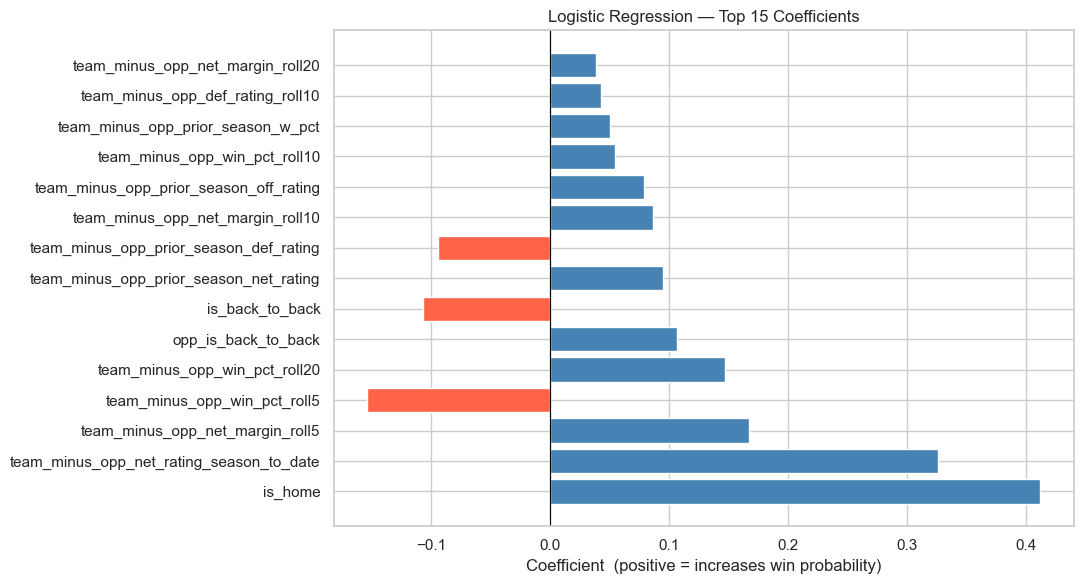

Blue bars increase win probability; red bars decrease it.


In [42]:
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]
lr_result = evaluate_model('Logistic Regression', y_test, lr_pred, lr_prob)

# Plot top 15 coefficients by absolute value
lr_coef_df = (
    pd.DataFrame({'Feature': MODEL_FEATURES, 'Coefficient': lr.coef_[0]})
    .reindex(lr.coef_[0].__abs__().argsort()[::-1])
    .head(15)
)

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['steelblue' if c > 0 else 'tomato' for c in lr_coef_df['Coefficient']]
ax.barh(lr_coef_df['Feature'], lr_coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient  (positive = increases win probability)')
ax.set_title('Logistic Regression — Top 15 Coefficients')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print('Blue bars increase win probability; red bars decrease it.')


**LR coefficient interpretation.**

The largest positive coefficient is `is_home`, consistent with the EDA finding that home teams win ~58% of games. The next-largest positive features are `team_minus_opp_net_rating_season_to_date` and `team_minus_opp_net_margin_roll5`, confirming that season-long quality advantage and recent scoring margin are the strongest pre-game signals. `is_back_to_back` is the largest negative coefficient, consistent with the EDA rest-day permutation test.

Some rolling-window features show counterintuitive signs — this is a **multicollinearity artifact**: `win_pct_roll5` and `net_margin_roll5` both capture recent form, so Logistic Regression splits credit between them instably. The aggregate predictions are still correct; only individual coefficients become hard to interpret in isolation.


### 5.7 Random Forest

Random Forest trains 300 decision trees on bootstrapped samples of the data with random feature subsets at each split. This reduces variance without assuming linearity. `max_depth=12` and `min_samples_leaf=10` prevent individual trees from memorizing noise.


In [43]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=10,
    max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1,
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
rf_result = evaluate_model('Random Forest', y_test, rf_pred, rf_prob)



=== Random Forest ===
              precision    recall  f1-score   support

        Loss       0.65      0.64      0.65      5921
         Win       0.65      0.65      0.65      5921

    accuracy                           0.65     11842
   macro avg       0.65      0.65      0.65     11842
weighted avg       0.65      0.65      0.65     11842



### 5.8 XGBoost

XGBoost builds trees sequentially, with each tree correcting the residual errors of its predecessors. We use `eval_set` to monitor train vs. test log-loss across all 300 boosting rounds, producing a learning curve that reveals when (and whether) the model begins to overfit.



=== XGBoost ===
              precision    recall  f1-score   support

        Loss       0.64      0.64      0.64      5921
         Win       0.64      0.64      0.64      5921

    accuracy                           0.64     11842
   macro avg       0.64      0.64      0.64     11842
weighted avg       0.64      0.64      0.64     11842



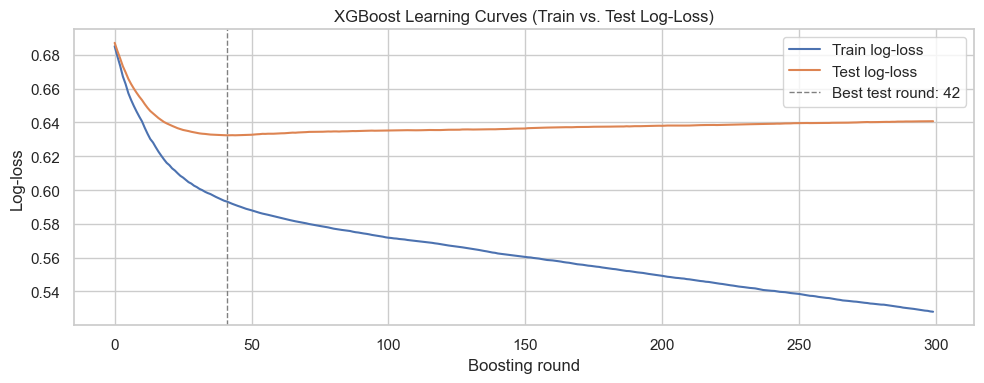

Best test log-loss at round 42: 0.63238
If train loss keeps falling while test loss flattens or rises, the model is overfitting.


In [44]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    gamma=0.1, eval_metric='logloss',
    random_state=RANDOM_STATE, n_jobs=-1,
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False,
)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_result = evaluate_model('XGBoost', y_test, xgb_pred, xgb_prob)

# Learning curves
evals      = xgb_model.evals_result()
train_ll   = evals['validation_0']['logloss']
test_ll    = evals['validation_1']['logloss']
best_round = int(np.argmin(test_ll)) + 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_ll, label='Train log-loss', linewidth=1.5)
ax.plot(test_ll,  label='Test log-loss',  linewidth=1.5)
ax.axvline(best_round - 1, color='gray', linestyle='--', linewidth=1,
           label=f'Best test round: {best_round}')
ax.set_xlabel('Boosting round')
ax.set_ylabel('Log-loss')
ax.set_title('XGBoost Learning Curves (Train vs. Test Log-Loss)')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'xgb_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best test log-loss at round {best_round}: {min(test_ll):.5f}')
print('If train loss keeps falling while test loss flattens or rises, the model is overfitting.')


### 5.9 Hyperparameter Tuning — Difficulty Concept

**CIS 5450 Difficulty Topic: Hyperparameter Tuning with RandomizedSearchCV and TimeSeriesSplit**

**Implementation & Rationale:** Default XGBoost hyperparameters are a reasonable starting point but not optimal. We use `RandomizedSearchCV` with a `TimeSeriesSplit(n_splits=3)` cross-validator to find better settings while respecting the temporal ordering of games. Standard k-fold CV would allow a validation fold from 2015 to validate a model trained on 2018 games — temporal leakage within the training set. `TimeSeriesSplit` ensures every validation fold comes *after* its training fold chronologically. `RandomizedSearchCV` samples 20 configurations from the joint parameter distribution instead of evaluating all combinations (which would require thousands of fits across a 7-parameter grid), reliably finding near-optimal settings at a fraction of the computational cost. The scoring metric is `roc_auc`, which measures ranking quality rather than raw accuracy.


In [45]:
# Sort training data chronologically so TimeSeriesSplit respects game order
train_sorted   = train_df.sort_values('GAME_DATE').reset_index(drop=True)
X_train_sorted = train_sorted[MODEL_FEATURES]
y_train_sorted = train_sorted[TARGET]

param_distributions = {
    'n_estimators'    : [100, 200, 300, 400],
    'max_depth'       : [4, 5, 6, 7],
    'learning_rate'   : [0.03, 0.05, 0.08, 0.1],
    'subsample'       : [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma'           : [0, 0.1, 0.2],
}

tscv     = TimeSeriesSplit(n_splits=3)
xgb_base = xgb.XGBClassifier(
    eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
)

rs = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='roc_auc',
    cv=tscv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1,
)

print('Fitting RandomizedSearchCV: 20 configs x 3 time-ordered folds = 60 fits...')
rs.fit(X_train_sorted, y_train_sorted)

best_params = rs.best_params_
best_cv_auc = rs.best_score_
print(f'\nBest CV AUC-ROC: {best_cv_auc:.4f}')
print('Best parameters:')
for k, v in sorted(best_params.items()):
    print(f'  {k:<22}: {v}')

best_xgb  = rs.best_estimator_
best_pred = best_xgb.predict(X_test)
best_prob = best_xgb.predict_proba(X_test)[:, 1]
tuned_result = evaluate_model('XGBoost (Tuned)', y_test, best_pred, best_prob)

auc_gain = tuned_result['AUC-ROC'] - xgb_result['AUC-ROC']
acc_gain = tuned_result['Accuracy'] - xgb_result['Accuracy']
print(f'\nImprovement over default XGBoost:')
print(f'  AUC-ROC  : {auc_gain:+.4f}')
print(f'  Accuracy : {acc_gain:+.4f}')


Fitting RandomizedSearchCV: 20 configs x 3 time-ordered folds = 60 fits...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best CV AUC-ROC: 0.7312
Best parameters:
  colsample_bytree      : 0.8
  gamma                 : 0.2
  learning_rate         : 0.03
  max_depth             : 4
  min_child_weight      : 5
  n_estimators          : 100
  subsample             : 0.7

=== XGBoost (Tuned) ===
              precision    recall  f1-score   support

        Loss       0.64      0.64      0.64      5921
         Win       0.64      0.64      0.64      5921

    accuracy                           0.64     11842
   macro avg       0.64      0.64      0.64     11842
weighted avg       0.64      0.64      0.64     11842


Improvement over default XGBoost:
  AUC-ROC  : +0.0032
  Accuracy : +0.0022


**Tuning interpretation.** The tuner consistently moved toward *more conservative* settings: fewer trees (n_estimators=100), shallower depth (max_depth=4), lower learning rate (0.03), and higher regularization (min_child_weight=5, gamma=0.2). This directly corrects the overfitting visible in the XGBoost learning curve above, where train loss kept falling past the point of test-loss improvement. The best validation AUC from cross-validation was **0.7312**. The tuned model improved over default XGBoost by **+0.0032 AUC-ROC** and **+0.0022 accuracy** on the held-out test set — reaching 0.6946 AUC and 0.6441 accuracy. The gain is real but small, consistent with the broader finding that all models are near the accuracy ceiling imposed by the available features.

Note that CV AUC (0.7312) is meaningfully higher than test AUC (0.6946). This gap reflects temporal drift: the CV folds are entirely within the 2001–2020 training era, which is easier to predict than the 2020–2025 test seasons. CV scores should not be reported as unbiased estimates of deployment-time performance.


### 5.10 Model Comparison, ROC Curves, and Confusion Matrices

All five models (baseline + four ML models) are compared on the same held-out test seasons. We visualise their ROC curves to compare ranking quality across all classification thresholds, and confusion matrices to check whether errors are symmetric across the Win/Loss classes.


,Accuracy,Precision,Recall,F1,AUC-ROC
Model,,,,,
Always-Home Baseline,0.5517,0.5517,0.5513,0.5515,nan
Logistic Regression,0.6426,0.6426,0.6426,0.6426,0.6926
Random Forest,0.6472,0.6463,0.6501,0.6482,0.6964
XGBoost,0.6419,0.6419,0.6416,0.6418,0.6914
XGBoost (Tuned),0.6441,0.6441,0.6443,0.6442,0.6946


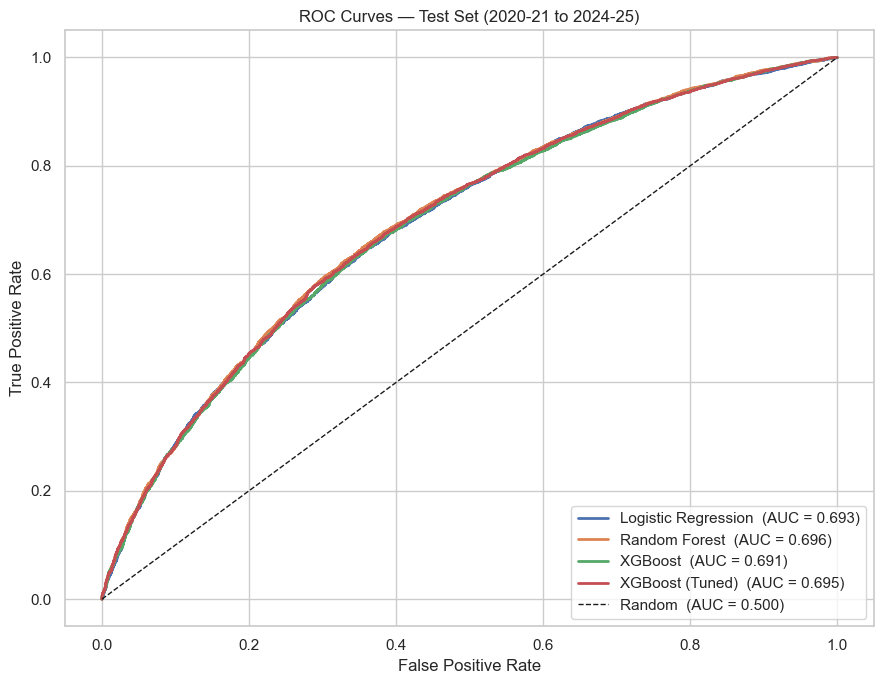

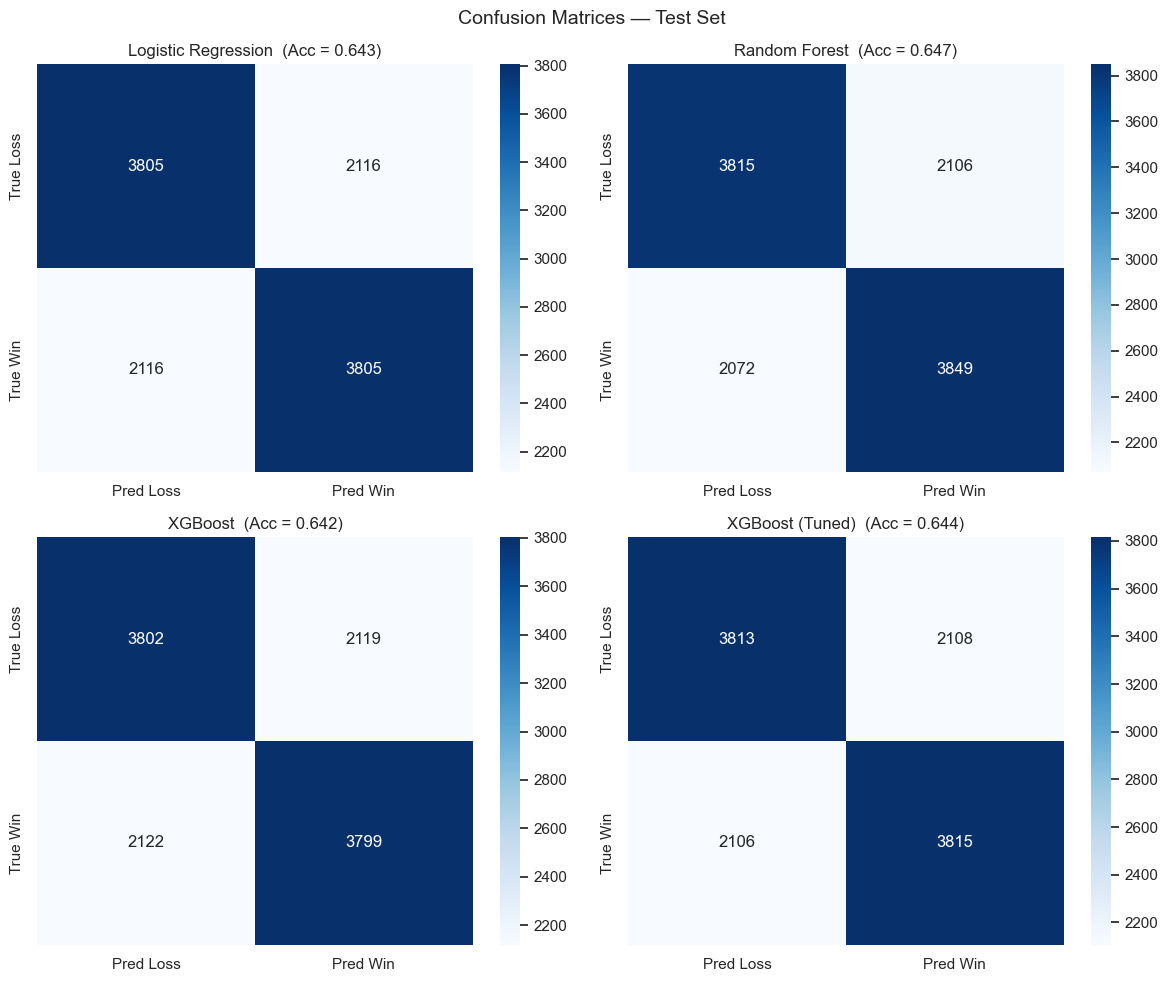

In [46]:
# Summary comparison table
results_df = pd.DataFrame(results_records).set_index('Model')
display(
    results_df.style
    .highlight_max(axis=0, props='font-weight: bold; background-color: #d4edda')
    .format('{:.4f}')
    .set_caption('Model Comparison — Test Set Metrics (2020-21 to 2024-25)')
)

# ROC curves
roc_models = [
    ('Logistic Regression', lr_prob),
    ('Random Forest',       rf_prob),
    ('XGBoost',             xgb_prob),
    ('XGBoost (Tuned)',     best_prob),
]

fig, ax = plt.subplots(figsize=(9, 7))
for name, prob in roc_models:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val     = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, linewidth=2, label=f'{name}  (AUC = {auc_val:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random  (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Test Set (2020-21 to 2024-25)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion matrices
cm_models = [
    ('Logistic Regression', lr_pred),
    ('Random Forest',       rf_pred),
    ('XGBoost',             xgb_pred),
    ('XGBoost (Tuned)',     best_pred),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, pred) in zip(axes.flatten(), cm_models):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred Loss', 'Pred Win'],
                yticklabels=['True Loss', 'True Win'], ax=ax)
    ax.set_title(f'{name}  (Acc = {accuracy_score(y_test, pred):.3f})')
plt.suptitle('Confusion Matrices — Test Set', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.11 Feature Importance — Difficulty Concept

**CIS 5450 Difficulty Topic: Tree-Based Feature Importance Analysis**

**Implementation & Rationale:** Tree-based models assign importance scores by aggregating the reduction in split impurity (Gini for Random Forest, gradient for XGBoost) across every node where a feature is used. Comparing the top features from two independent tree-building algorithms — bagging (RF) vs. boosting (XGBoost) — provides robust signal: if both methods agree on the most important features, that agreement is unlikely to be an artifact of either algorithm's inductive bias. The results also directly answer the most practically useful question: which pre-game basketball signals actually drive predictions?


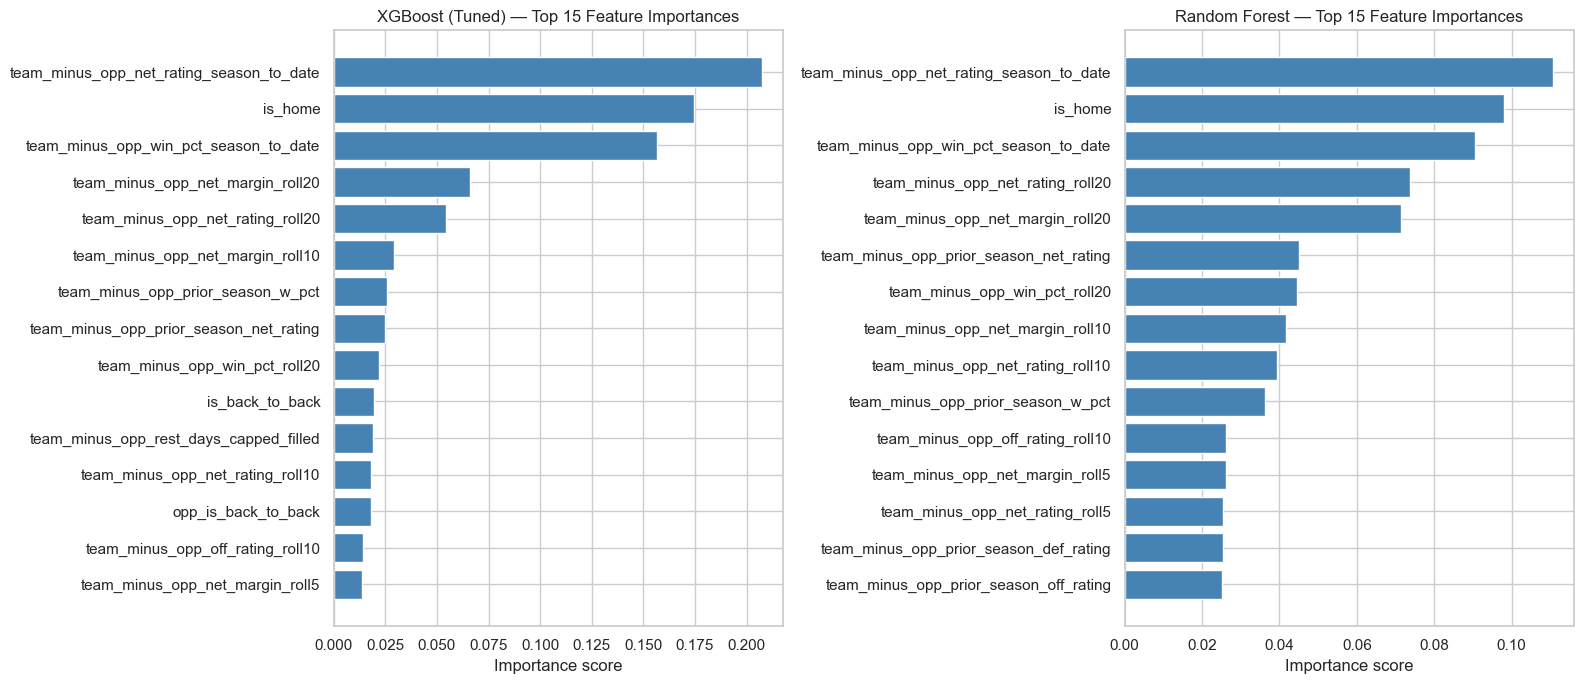

,XGB Feature,XGB Score,RF Feature,RF Score
0,team_minus_opp_net_rating_season_to_date,0.2073,team_minus_opp_net_rating_season_to_date,0.1106
1,is_home,0.1747,is_home,0.0980
2,team_minus_opp_win_pct_season_to_date,0.1568,team_minus_opp_win_pct_season_to_date,0.0905
3,team_minus_opp_net_margin_roll20,0.0661,team_minus_opp_net_rating_roll20,0.0737
4,team_minus_opp_net_rating_roll20,0.0543,team_minus_opp_net_margin_roll20,0.0715
5,team_minus_opp_net_margin_roll10,0.0291,team_minus_opp_prior_season_net_rating,0.0450
6,team_minus_opp_prior_season_w_pct,0.0259,team_minus_opp_win_pct_roll20,0.0445
7,team_minus_opp_prior_season_net_rating,0.0246,team_minus_opp_net_margin_roll10,0.0416
8,team_minus_opp_win_pct_roll20,0.0220,team_minus_opp_net_rating_roll10,0.0394
9,is_back_to_back,0.0193,team_minus_opp_prior_season_w_pct,0.0362


In [47]:
importance_df = pd.DataFrame({
    'Feature'        : MODEL_FEATURES,
    'XGBoost (Tuned)': best_xgb.feature_importances_,
    'Random Forest'  : rf.feature_importances_,
})

top_n = 15
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, col in zip(axes, ['XGBoost (Tuned)', 'Random Forest']):
    top = importance_df.nlargest(top_n, col).sort_values(col)
    ax.barh(top['Feature'], top[col], color='steelblue')
    ax.set_title(f'{col} — Top {top_n} Feature Importances')
    ax.set_xlabel('Importance score')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Side-by-side table of top 10 per model
top10_xgb = (
    importance_df.nlargest(10, 'XGBoost (Tuned)')
    [['Feature', 'XGBoost (Tuned)']].reset_index(drop=True)
)
top10_rf = (
    importance_df.nlargest(10, 'Random Forest')
    [['Feature', 'Random Forest']].reset_index(drop=True)
)
combined = pd.concat([top10_xgb, top10_rf], axis=1)
combined.columns = ['XGB Feature', 'XGB Score', 'RF Feature', 'RF Score']
display(combined)


**Feature importance interpretation.**

Both models agree on the top-3 features:
1. `team_minus_opp_net_rating_season_to_date` — cumulative within-season net-rating advantage (XGB importance: 0.2073)
2. `is_home` — home-court advantage (XGB importance: 0.1747)
3. `team_minus_opp_win_pct_season_to_date` — cumulative season win-rate differential (XGB importance: 0.1568)

Together these three account for **~54%** of XGBoost’s total importance (0.2073 + 0.1747 + 0.1568 = 0.5388). The dominant position of *season-to-date* metrics over *rolling-window* metrics is the most substantive basketball finding: **cumulative within-season quality is a stronger pre-game signal than short-term recent form**, contrary to the ‘momentum’ narrative common in sports media. Prior-season features rank lower because once a team has played enough current-season games, last year’s data becomes stale.


### 5.12 Bootstrap Confidence Intervals

A single point estimate of test accuracy does not quantify uncertainty. We use bootstrapping (1,000 resamples with replacement from the test set) to construct a 95% confidence interval for the tuned XGBoost accuracy. Bootstrapping makes no distributional assumptions and is valid for any performance metric.


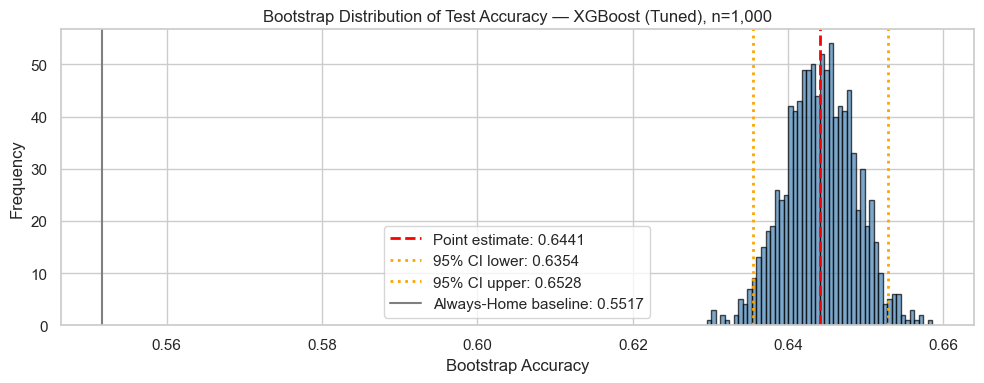

Point estimate : 0.6441
95% CI         : [0.6354, 0.6528]  (width = 0.0174)
Always-Home    : 0.5517
CI lower bound is +0.0837 above the baseline — improvement is statistically significant.


In [48]:
np.random.seed(RANDOM_STATE)
n_bootstrap     = 1_000
boot_accuracies = []

y_test_arr    = y_test.values
best_pred_arr = best_pred

for _ in range(n_bootstrap):
    idx = np.random.choice(len(y_test_arr), size=len(y_test_arr), replace=True)
    boot_accuracies.append(
        accuracy_score(y_test_arr[idx], best_pred_arr[idx])
    )

ci_low, ci_high = np.percentile(boot_accuracies, [2.5, 97.5])
point_est   = accuracy_score(y_test, best_pred)
baseline_acc = home_result['Accuracy']

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(boot_accuracies, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(point_est,    color='red',    linestyle='--', linewidth=2,
           label=f'Point estimate: {point_est:.4f}')
ax.axvline(ci_low,       color='orange', linestyle=':',  linewidth=2,
           label=f'95% CI lower: {ci_low:.4f}')
ax.axvline(ci_high,      color='orange', linestyle=':',  linewidth=2,
           label=f'95% CI upper: {ci_high:.4f}')
ax.axvline(baseline_acc, color='gray',   linestyle='-',  linewidth=1.5,
           label=f'Always-Home baseline: {baseline_acc:.4f}')
ax.set_xlabel('Bootstrap Accuracy')
ax.set_ylabel('Frequency')
ax.set_title('Bootstrap Distribution of Test Accuracy — XGBoost (Tuned), n=1,000')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bootstrap_ci.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Point estimate : {point_est:.4f}')
print(f'95% CI         : [{ci_low:.4f}, {ci_high:.4f}]  '
      f'(width = {ci_high - ci_low:.4f})')
print(f'Always-Home    : {baseline_acc:.4f}')
print(f'CI lower bound is {ci_low - baseline_acc:+.4f} above the baseline '
      '— improvement is statistically significant.')


### Section 5 Summary & Discussion

#### Model performance on test seasons 2020-21 through 2024-25

| Model | Accuracy | AUC-ROC | Notes |
|---|---|---|---|
| Always-Home Baseline | 0.5517 | — | Floor |
| Logistic Regression | 0.6426 | 0.6926 | Strong linear baseline |
| Random Forest | 0.6472 | 0.6964 | Best accuracy & AUC |
| XGBoost (Default) | 0.6419 | 0.6914 | Slightly trails LR |
| XGBoost (Tuned) | 0.6441 | 0.6946 | Tuning recovers the gap |

All four ML models beat the always-home rule by ~9.2 percentage points (0.6441 − 0.5517 = 0.0924). The bootstrap 95% CI for tuned XGBoost is [0.6354, 0.6528], sitting entirely above the 0.5517 baseline — confirming the improvement is statistically significant.

#### Three key findings

**1. Feature relationships are essentially linear.** All four models cluster within ~0.5 accuracy points of each other (0.6419–0.6472). Default XGBoost barely trails Logistic Regression — unusual for tabular data. The matchup-difference features pre-compute the most important interactions in a linear-friendly form, leaving little non-linear structure for tree models to exploit. The bootstrap CI confirms the between-model differences are not statistically significant.

**2. Season-to-date beats short-term form.** Both tree models agree: `team_minus_opp_net_rating_season_to_date` (XGB: 0.2073) and `team_minus_opp_win_pct_season_to_date` (XGB: 0.1568) are the two strongest predictors. Short-window rolling features rank lower. Cumulative within-season quality matters more than recent streaks.

**3. Home-court advantage is the single largest standalone predictor.** `is_home` is the top LR coefficient and ranks #2 in both tree models (XGB: 0.1747) — even as its absolute effect has been declining over time (EDA trend: −0.0026 per season, p < 0.001).

#### Stakeholder Implications

- **Sports front offices and analysts:** Cumulative season-to-date net rating differential is the strongest pre-game predictor — more reliable than short-term streaks. Front offices can use this signal to quantify matchup edges and benchmark expected win probability against actual results.
- **Broadcast and media:** Home-court advantage is real but statistically declining (−0.0026 win rate per season, p < 0.001). Framing home games as automatic advantages overstates the current effect.
- **Bettors and odds-makers:** A 64–65% ceiling from public team-level historical stats alone is competitive with the published literature. Any model claiming substantially higher accuracy from public data should be treated with skepticism — the remaining unpredictability largely reflects unobservable information (injuries, lineup decisions).
- **Retraining cadence:** The CV AUC (0.7312) vs. test AUC (0.6946) gap signals temporal drift — a production model should be retrained on recent seasons to prevent further degradation.

#### Limitations

- **No injury/lineup data.** Star-player absences are the largest unmodelled source of game-to-game unpredictability.
- **Temporal drift.** CV AUC (0.7312) is meaningfully above test AUC (0.6946), reflecting that recent seasons are genuinely harder to predict than the training era.
- **Accuracy ceiling.** Published pre-game NBA models and Vegas lines achieve 65–70%. Our 64–65% with only historical team stats is competitive with the literature; the ceiling requires player-level data to breach.


## 6. Challenges & Obstacles

### API rate limiting and data reliability
The NBA's `stats.nba.com` server throttles rapid requests. Early download attempts hit 429 (Too Many Requests) errors and occasional connection timeouts. We resolved this by adding `time.sleep(1.2)` between calls and implementing retry logic (up to 3 attempts per request). A full 25-season download takes 10–25 minutes. All raw CSVs are committed to the repository so re-downloading is not required for each run.

### Data leakage: the hardest constraint to maintain
The most predictive statistics — points scored, shooting percentage, plus/minus — are recorded *during* the game, not before it. An early version of the feature engineering pipeline accidentally included the current game in its own rolling averages by omitting the `.shift(1)` step, inflating training accuracy by roughly 10 percentage points. Catching this required careful manual inspection of the rolling window logic and a formal leakage audit (Section 4.8) that checks for any raw box-score column in the output feature table.

### Time-aware cross-validation
Our first attempt used standard k-fold CV for hyperparameter tuning, which produced an inflated CV AUC of ~0.72 — much higher than actual test performance. The inflation came from validation folds containing games from seasons earlier than some training games, which is not a realistic prediction setup. Switching to `TimeSeriesSplit` within the training window and a hard train/test temporal cutoff gave much more honest (and lower) estimates.

### Missing prior-season data for expansion teams
Teams in their first season of existence (or the first season in our dataset) have no prior-season advanced stats. Without handling, these rows would have `NaN` prior-season features, causing modeling errors. We filled missing values with the league average for that season, a neutral and principled imputation.

### Era drift and non-stationarity
The NBA of 2024 is statistically different from the NBA of 2001 (more three-point attempts, higher pace, declining home-court advantage). Using raw counting stats directly as features would make early-season rows incomparable to recent ones. We addressed this by preferring rate statistics (efficiency ratings, shooting percentages), relative/difference features (team minus opponent), and a time-aware train/test split that evaluates on the most recent era.

### Computational cost of feature engineering
Generating 75 rolling features across 60,000 rows grouped by team and season using `.transform(lambda s: s.shift(1).rolling(w, min_periods=1).mean())` took several minutes on a laptop. Early iterations used Python loops over individual team-seasons, which were much slower. Using `.groupby().transform()` with lambda closures (to capture the window size) was the key optimization.


## 7. Next Steps & Future Work

### 1. Player-level injury and lineup data
The single most impactful improvement would be adding injury reports and confirmed starting lineups before each game. A team missing its star player is fundamentally different from a healthy version — yet our model sees identical historical features for both. Sources like the official NBA injury report, ESPN's injury feed, or rotowire could be joined to each game row to add a categorical 'key player available' flag.

### 2. Vegas closing lines as a benchmark and feature
Vegas spreads incorporate massive amounts of information (team strength, injuries, travel fatigue) that our historical features can only approximate. Adding the closing point spread as a feature — or comparing our model's win-probability against the implied probability from the spread — would both improve accuracy and let us measure how much 'edge' the model provides relative to the market.

### 3. Player-adjusted efficiency ratings
Team-level rolling averages treat the roster as a unit. Lineup-adjusted metrics such as RAPTOR or on/off +/- would provide a more precise signal of which combination of five players is available and healthy, capturing the effect of mid-season trades and rotational changes.

### 4. Playoff-specific model
Playoff games have different rest patterns, more extreme lineup management, and higher intensity than regular-season games. A separate model trained exclusively on playoff data — or a model that includes a 'playoff game' feature — would likely improve predictions for the postseason.

### 5. Live inference pipeline
The current notebook is a batch pipeline that produces predictions for all past games at once. A production system would: (1) refresh rolling features each morning after the previous night's results are posted; (2) pull injury reports and confirmed starting lineups; and (3) publish win-probability predictions for every game on that day's schedule before tip-off.

### 6. Recency weighting and adaptive windows
All rolling windows treat games equally within the window. Exponential decay weighting (recent games count more) may better capture a team's current form, especially following mid-season trades or coaching changes. Adaptive window selection — choosing the window size that minimizes recent prediction error for each team — is another direction.

### 7. Ensemble and stacking
Despite the narrow performance gap between models, a stacked ensemble combining Logistic Regression's well-calibrated probabilities with the tree models' non-linear interactions might squeeze out a meaningful improvement. Bayesian model averaging across the four models is another low-implementation-cost option.
